# Explainable Machine Learning for Early Dropout Prediction and Student Segmentation in Higher Education

**Author:** Eduardo R. Magdaluyo, Jr.  
**Purpose:** Capstone Project,                                                     Post Graduate Diploma in AI/ML, Asian Institute of Management

## Cell 1 — Install packages in Google Colab

Run this cell first whenever a new Colab runtime is started. Package installations
apply only to the active Colab session.


## Cell 2 — Imports and reproducibility

In [60]:
# Imports the required libraries, configures reproducibility,
# and checks the availability of optional packages.


# ------------------------------------------------------------
# Standard Python libraries
# ------------------------------------------------------------

import os
import json
import random
import warnings
from pathlib import Path
from datetime import datetime


# ------------------------------------------------------------
# Data handling and visualization
# ------------------------------------------------------------

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# General configuration
# ------------------------------------------------------------

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Scikit-learn utilities
# ------------------------------------------------------------

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)


# ------------------------------------------------------------
# Machine-learning models
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression

from sklearn.tree import (
    DecisionTreeClassifier
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC


# ------------------------------------------------------------
# Feature selection and dimensionality reduction
# ------------------------------------------------------------

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE


# ------------------------------------------------------------
# Model calibration and explainability
# ------------------------------------------------------------

from sklearn.calibration import (
    CalibratedClassifierCV,
    CalibrationDisplay
)

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)


# ------------------------------------------------------------
# Clustering analysis
# ------------------------------------------------------------

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)


# ------------------------------------------------------------
# Model evaluation metrics
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)


# ------------------------------------------------------------
# Optional SHAP package
# ------------------------------------------------------------

try:

    import shap

    SHAP_AVAILABLE = True

except Exception:

    SHAP_AVAILABLE = False


# ------------------------------------------------------------
# Optional Fairlearn package
# ------------------------------------------------------------

try:

    from fairlearn.metrics import (
        MetricFrame,
        selection_rate,
        false_positive_rate,
        false_negative_rate,
        demographic_parity_difference,
        demographic_parity_ratio,
        equalized_odds_difference,
        equalized_odds_ratio
    )

    FAIRLEARN_AVAILABLE = True

except Exception:

    FAIRLEARN_AVAILABLE = False


# ------------------------------------------------------------
# Reproducibility settings
# ------------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

pd.set_option(
    "display.max_columns",
    100
)


# ------------------------------------------------------------
# Confirm environment configuration
# ------------------------------------------------------------

print(f"Random state: {RANDOM_STATE}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print(f"Fairlearn available: {FAIRLEARN_AVAILABLE}")

Random state: 42
SHAP available: True
Fairlearn available: True


In [61]:
# Installs the additional libraries required for data download,
# explainability, fairness evaluation, model persistence, and reporting.
#
# `%pip` is used instead of `!pip` because it installs packages into
# the Python environment associated with the current Colab notebook.

%pip install -q gdown shap fairlearn openpyxl tabulate joblib


In [62]:
# ------------------------------------------------------------
# Google Drive download utility
# ------------------------------------------------------------
# gdown is used to retrieve the study dataset from its shared
# Google Drive file ID when the CSV is not already available.

import gdown


In [63]:
# Downloads the student dropout dataset used in this study.
#
# In Google Colab, the working directory is normally /content.
# The dataset is stored under data/raw so that the same notebook
# also follows a conventional GitHub repository structure.

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

file_id = "1JlIg8PKiHYqdx4khqWg98rEP2OsnNGKn"
output_path = DATA_DIR / "student_dropout_data.csv"

if output_path.exists():
    print(f"Dataset already available at:\n{output_path.resolve()}")
else:
    downloaded_file = gdown.download(
        id=file_id,
        output=str(output_path),
        quiet=False
    )

    if downloaded_file is None or not output_path.exists():
        raise RuntimeError(
            "The dataset could not be downloaded. Check the Google Drive "
            "sharing permission or upload the CSV manually to data/raw/."
        )

    print(f"\nDataset downloaded to:\n{output_path.resolve()}")


Dataset already available at:
/content/data/raw/student_dropout_data.csv


## Cell 3 — GitHub-compatible project folders and run configuration

The current Colab working directory is treated as the repository root. This avoids
creating an unnecessary nested `student_dropout_capstone` folder when the notebook
is later uploaded to or run from GitHub.


In [64]:
# Creates a GitHub-compatible project directory structure and saves
# the main analysis settings for reproducibility.

# ------------------------------------------------------------
# Repository root
# ------------------------------------------------------------
# In a standard Google Colab session, this resolves to /content.
# When the notebook is run after cloning a GitHub repository and
# changing into that repository, it resolves to the repository root.

ROOT = Path.cwd()

PATHS = {
    key: ROOT / folder
    for key, folder in {
        "raw": "data/raw",
        "processed": "data/processed",
        "models": "models",
        "reports": "reports",
        "figures": "reports/figures",
        "tables": "reports/tables",
        "configs": "configs",
        "notebooks": "notebooks",
        "slides": "slides"
    }.items()
}

# ------------------------------------------------------------
# Create folders if they do not already exist
# ------------------------------------------------------------

for project_path in PATHS.values():
    project_path.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# Save the main run settings
# ------------------------------------------------------------

CONFIG = {
    "project_title": (
        "Explainable Machine Learning for Early Dropout Prediction "
        "and Student Segmentation in Higher Education"
    ),
    "execution_environment": "Google Colab",
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
    "cv_folds": 5,
    "primary_metric": "F1",
    "positive_class": "Dropout",
    "generated_at": datetime.now().isoformat()
}

config_path = PATHS["configs"] / "run_config.json"

with config_path.open("w", encoding="utf-8") as config_file:
    json.dump(
        CONFIG,
        config_file,
        indent=4
    )

print(f"Repository root: {ROOT.resolve()}")
print(f"Configuration saved to: {config_path.resolve()}")


Repository root: /content
Configuration saved to: /content/configs/run_config.json


## Cell 4 — Load dataset

In [65]:
# Locates the dataset, loads it into a DataFrame, and standardizes
# column names for consistent analysis.

# ------------------------------------------------------------
# Search for the dataset in expected Colab/GitHub locations
# ------------------------------------------------------------

candidate_paths = [
    PATHS["raw"] / "student_dropout_data.csv",
    Path("student_dropout_data.csv"),
    Path("/content/data/raw/student_dropout_data.csv"),
    Path("/content/student_dropout_data.csv")
]

DATA_PATH = next(
    (candidate for candidate in candidate_paths if candidate.exists()),
    None
)

# ------------------------------------------------------------
# Verify that the dataset exists
# ------------------------------------------------------------

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Run the dataset-download cell or upload "
        "student_dropout_data.csv to the data/raw folder."
    )

# ------------------------------------------------------------
# Load the dataset
# ------------------------------------------------------------
# The UCI dataset is normally semicolon-delimited. If only one
# column is detected, the file is reloaded using comma separation.

df = pd.read_csv(DATA_PATH, sep=";")

if df.shape[1] == 1:
    df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH.resolve()}")
print(f"Dataset shape: {df.shape}")

# ------------------------------------------------------------
# Standardize column names
# ------------------------------------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

display(df.head())


Dataset loaded from: /content/data/raw/student_dropout_data.csv
Dataset shape: (4424, 37)


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mother_s_qualification,father_s_qualification,mother_s_occupation,father_s_occupation,admission_grade,displaced,educational_special_needs,debtor,tuition_fees_up_to_date,gender,scholarship_holder,age_at_enrollment,international,curricular_units_1st_sem_credited,curricular_units_1st_sem_enrolled,curricular_units_1st_sem_evaluations,curricular_units_1st_sem_approved,curricular_units_1st_sem_grade,curricular_units_1st_sem_without_evaluations,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Dataset source and justification

Use the official UCI citation for **Predict Students’ Dropout and Academic Success**. The dataset is suitable because it includes demographic, socioeconomic, admission, academic-progression, and macroeconomic variables, enabling prediction, segmentation, explainability, and fairness analysis.

## Cell 5 — Dataset overview, missing values, duplicates, and target distribution

Rows: 4,424
Columns: 37
Duplicate rows: 0
Missing cells: 0

Student outcome distribution:


,Outcome,Count,Percent
0,Graduate,2209,49.93
1,Dropout,1421,32.12
2,Enrolled,794,17.95



Variables with the most missing values:


,Missing count,Missing_percent
marital_status,0,0.0
application_mode,0,0.0
application_order,0,0.0
course,0,0.0
daytime_evening_attendance,0,0.0
previous_qualification,0,0.0
previous_qualification_grade,0,0.0
nacionality,0,0.0
mother_s_qualification,0,0.0
father_s_qualification,0,0.0



Binary dropout target distribution:


,Dropout_Target,Count
0,0,3003
1,1,1421


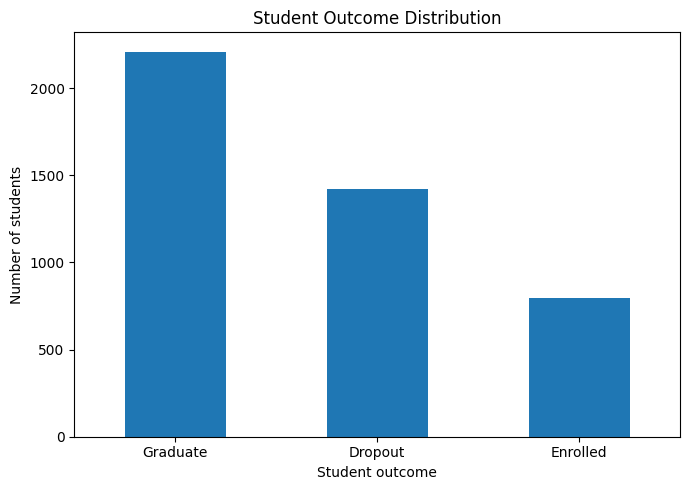


Target distribution figure saved to:
/content/reports/figures/target_distribution.png


In [66]:
# Summarizes dataset size, data quality, missing values,
# duplicates, and student outcome distribution.


# ------------------------------------------------------------
# Basic dataset overview
# ------------------------------------------------------------

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Missing cells: {df.isna().sum().sum():,}")


# ------------------------------------------------------------
# Target-class distribution
# ------------------------------------------------------------

target_summary = (
    df["target"]
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="Count")
)

target_summary["Percent"] = (
    target_summary["Count"] / len(df) * 100
).round(2)

print("\nStudent outcome distribution:")
display(target_summary)


# ------------------------------------------------------------
# Missing-value summary
# ------------------------------------------------------------

missing = (
    df.isna()
    .sum()
    .to_frame("Missing count")
    .assign(
        Missing_percent=lambda x:
        (x["Missing count"] / len(df) * 100).round(2)
    )
    .sort_values(
        "Missing count",
        ascending=False
    )
)

print("\nVariables with the most missing values:")
display(missing.head(20))


# ------------------------------------------------------------
# Create the binary dropout target
# ------------------------------------------------------------
# Dropout = 1; Graduate and Enrolled = 0.

df["Dropout_Target"] = (
    df["target"] == "Dropout"
).astype(int)

print(
    "\nBinary dropout target distribution:"
)
display(
    df["Dropout_Target"]
    .value_counts()
    .sort_index()
    .rename_axis("Dropout_Target")
    .reset_index(name="Count")
)


# ------------------------------------------------------------
# Plot and save the target distribution
# ------------------------------------------------------------

target_counts = df["target"].value_counts()

plt.figure(figsize=(7, 5))

target_counts.plot(
    kind="bar"
)

plt.title("Student Outcome Distribution")
plt.xlabel("Student outcome")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.tight_layout()

target_figure_path = (
    PATHS["figures"] / "target_distribution.png"
)

plt.savefig(
    target_figure_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nTarget distribution figure saved to:\n"
    f"{target_figure_path.resolve()}"
)


## Cell 6 — Complete data dictionary

In [67]:
# Documents variable roles, data types, units, missing values,
# ranges, and example values for all dataset columns.


# ------------------------------------------------------------
# Define units or measurement scales
# ------------------------------------------------------------

unit_notes = {
    "Previous qualification (grade)": "Institutional grade scale",
    "Admission grade": "Institutional grade scale",
    "Curricular units 1st sem (grade)": "Academic grade",
    "Curricular units 2nd sem (grade)": "Academic grade",
    "Age at enrollment": "Years",
    "Unemployment rate": "Percent",
    "Inflation rate": "Percent",
    "GDP": "Economic indicator"
}


# ------------------------------------------------------------
# Build the data dictionary
# ------------------------------------------------------------

dictionary_rows = []

for variable in df.columns:

    series = df[variable]
    is_numeric = pd.api.types.is_numeric_dtype(series)

    dictionary_rows.append({
        "Variable": variable,
        "Role": (
            "Target"
            if variable in ["Target", "Dropout_Target"]
            else "Predictor"
        ),
        "Data type": str(series.dtype),
        "Units/scale": unit_notes.get(
            variable,
            "Code, category, or count"
        ),
        "Missing count": int(series.isna().sum()),
        "Missing percent": round(
            series.isna().mean() * 100,
            3
        ),
        "Unique values": int(series.nunique()),
        "Minimum": (
            float(series.min())
            if is_numeric and series.notna().any()
            else None
        ),
        "Maximum": (
            float(series.max())
            if is_numeric and series.notna().any()
            else None
        ),
        "Median": (
            float(series.median())
            if is_numeric and series.notna().any()
            else None
        ),
        "Examples": ", ".join(
            map(
                str,
                series.dropna().unique()[:8]
            )
        )
    })


data_dictionary = pd.DataFrame(dictionary_rows)


# ------------------------------------------------------------
# Save the data dictionary
# ------------------------------------------------------------

csv_path = PATHS["tables"] / "data_dictionary.csv"
excel_path = PATHS["tables"] / "data_dictionary.xlsx"

data_dictionary.to_csv(
    csv_path,
    index=False
)

data_dictionary.to_excel(
    excel_path,
    index=False
)


# ------------------------------------------------------------
# Display the completed dictionary
# ------------------------------------------------------------

print(
    f"Data dictionary created for "
    f"{len(data_dictionary)} variables."
)

display(data_dictionary)

print("\nFiles saved to:")
print(csv_path.resolve())
print(excel_path.resolve())

Data dictionary created for 38 variables.


,Variable,Role,Data type,Units/scale,Missing count,Missing percent,Unique values,Minimum,Maximum,Median,Examples
0,marital_status,Predictor,int64,"Code, category, or count",0,0.0,6,1.00,6.000000,1.000000,"1, 2, 4, 3, 5, 6"
1,application_mode,Predictor,int64,"Code, category, or count",0,0.0,18,1.00,57.000000,17.000000,"17, 15, 1, 39, 18, 53, 44, 51"
2,application_order,Predictor,int64,"Code, category, or count",0,0.0,8,0.00,9.000000,1.000000,"5, 1, 2, 4, 3, 6, 9, 0"
3,course,Predictor,int64,"Code, category, or count",0,0.0,17,33.00,9991.000000,9238.000000,"171, 9254, 9070, 9773, 8014, 9991, 9500, 9238"
4,daytime_evening_attendance,Predictor,int64,"Code, category, or count",0,0.0,2,0.00,1.000000,1.000000,"1, 0"
5,previous_qualification,Predictor,int64,"Code, category, or count",0,0.0,17,1.00,43.000000,1.000000,"1, 19, 42, 39, 10, 3, 40, 2"
6,previous_qualification_grade,Predictor,float64,"Code, category, or count",0,0.0,101,95.00,190.000000,133.100000,"122.0, 160.0, 100.0, 133.1, 142.0, 119.0, 137...."
7,nacionality,Predictor,int64,"Code, category, or count",0,0.0,21,1.00,109.000000,1.000000,"1, 62, 6, 41, 26, 103, 13, 25"
8,mother_s_qualification,Predictor,int64,"Code, category, or count",0,0.0,29,1.00,44.000000,19.000000,"19, 1, 37, 38, 3, 4, 42, 2"
9,father_s_qualification,Predictor,int64,"Code, category, or count",0,0.0,34,1.00,44.000000,19.000000,"12, 3, 37, 38, 1, 19, 5, 4"



Files saved to:
/content/reports/tables/data_dictionary.csv
/content/reports/tables/data_dictionary.xlsx


## Cell 7 — Outlier audit and treatment decision

In [68]:
# Purpose:
# • Identify potential outliers using the 1.5 × IQR rule.
# • Summarize the frequency of outliers.
# • Support an evidence-based treatment decision.
# ============================================================


# ------------------------------------------------------------
# Define continuous variables for outlier assessment
# ------------------------------------------------------------
# Only continuous variables are evaluated using the IQR method.

continuous = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]


# ------------------------------------------------------------
# Retain only variables available in the dataset
# ------------------------------------------------------------

available_continuous = [
    variable for variable in continuous
    if variable in df.columns
]

missing_continuous = [
    variable for variable in continuous
    if variable not in df.columns
]

print(f"Variables assessed: {len(available_continuous)}")

if missing_continuous:
    print("Variables not found:", missing_continuous)


# ------------------------------------------------------------
# Detect potential outliers using the 1.5 × IQR rule
# ------------------------------------------------------------

outlier_records = []

for variable in available_continuous:

    series = pd.to_numeric(df[variable], errors="coerce")

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    outlier_records.append({
        "Variable": variable,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower": lower_bound,
        "Upper": upper_bound,
        "Outliers": int(outlier_mask.sum()),
        "Percent": round(outlier_mask.mean() * 100, 2)
    })


# ------------------------------------------------------------
# Display and save the outlier summary
# ------------------------------------------------------------

outlier_summary = pd.DataFrame(outlier_records)

display(outlier_summary.round(3))

outlier_summary.to_csv(
    PATHS["tables"] / "outlier_summary.csv",
    index=False
)


# ------------------------------------------------------------
# Optional plausibility check
# ------------------------------------------------------------
# Screen for values outside reasonable ranges.

plausibility_rules = {
    "Previous qualification (grade)": (0, 200),
    "Admission grade": (0, 200),
    "Age at enrollment": (10, 100),
    "Curricular units 1st sem (grade)": (0, 20),
    "Curricular units 2nd sem (grade)": (0, 20),
    "Unemployment rate": (0, 100),
    "Inflation rate": (-20, 100)
}

impossible_records = []

for variable, (minimum, maximum) in plausibility_rules.items():

    if variable not in df.columns:
        continue

    series = pd.to_numeric(df[variable], errors="coerce")

    impossible_records.append({
        "Variable": variable,
        "Potentially impossible values":
        int(((series < minimum) | (series > maximum)).sum())
    })

display(pd.DataFrame(impossible_records))


# ------------------------------------------------------------
# Treatment decision
# ------------------------------------------------------------
# Statistical outliers are retained unless they are impossible
# or clearly caused by data-entry errors. This preserves valid
# high-risk student profiles for model development.

print("\nOUTLIER TREATMENT DECISION")
print("-" * 50)
print("• Retain statistically plausible outliers.")
print("• Investigate impossible or miscoded values.")
print("• Remove observations only when confirmed invalid.")
print("• No automatic trimming or winsorization applied.")

Variables assessed: 0
Variables not found: ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Unemployment rate', 'Inflation rate', 'GDP']


""


""



OUTLIER TREATMENT DECISION
--------------------------------------------------
• Retain statistically plausible outliers.
• Investigate impossible or miscoded values.
• Remove observations only when confirmed invalid.
• No automatic trimming or winsorization applied.


## Cell 8 — Applied EDA across sensitive and operational groups

In [69]:
# Examines dropout rates across selected demographic, financial,
# and operational groups to identify potential differences in
# student outcomes.

import re


# ------------------------------------------------------------
# Variables for subgroup analysis
# ------------------------------------------------------------

group_variables = [
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "International",
    "Daytime/evening attendance"
]


# ------------------------------------------------------------
# Analyze dropout rate for each group
# ------------------------------------------------------------

for variable in group_variables:

    if variable not in df.columns:
        continue

    summary = (
        df.groupby(variable)["Dropout_Target"]
          .agg(["mean", "count"])
          .reset_index()
    )

    summary["Dropout rate (%)"] = (
        summary["mean"] * 100
    ).round(2)

    summary.rename(
        columns={
            "mean": "Dropout proportion",
            "count": "Number of students"
        },
        inplace=True
    )

    print(f"\nDropout analysis by {variable}:")
    display(summary)


    # --------------------------------------------------------
    # Plot subgroup dropout rates
    # --------------------------------------------------------

    plt.figure(figsize=(6, 4))

    plt.bar(
        summary[variable].astype(str),
        summary["Dropout rate (%)"]
    )

    plt.title(f"Dropout Rate by {variable}")
    plt.xlabel(variable)
    plt.ylabel("Dropout Rate (%)")

    plt.tight_layout()

    safe_name = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        variable.lower()
    )

    figure_path = (
        PATHS["figures"] /
        f"dropout_by_{safe_name}.png"
    )

    plt.savefig(
        figure_path,
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

## Cell 9 — Academic distributions and correlations

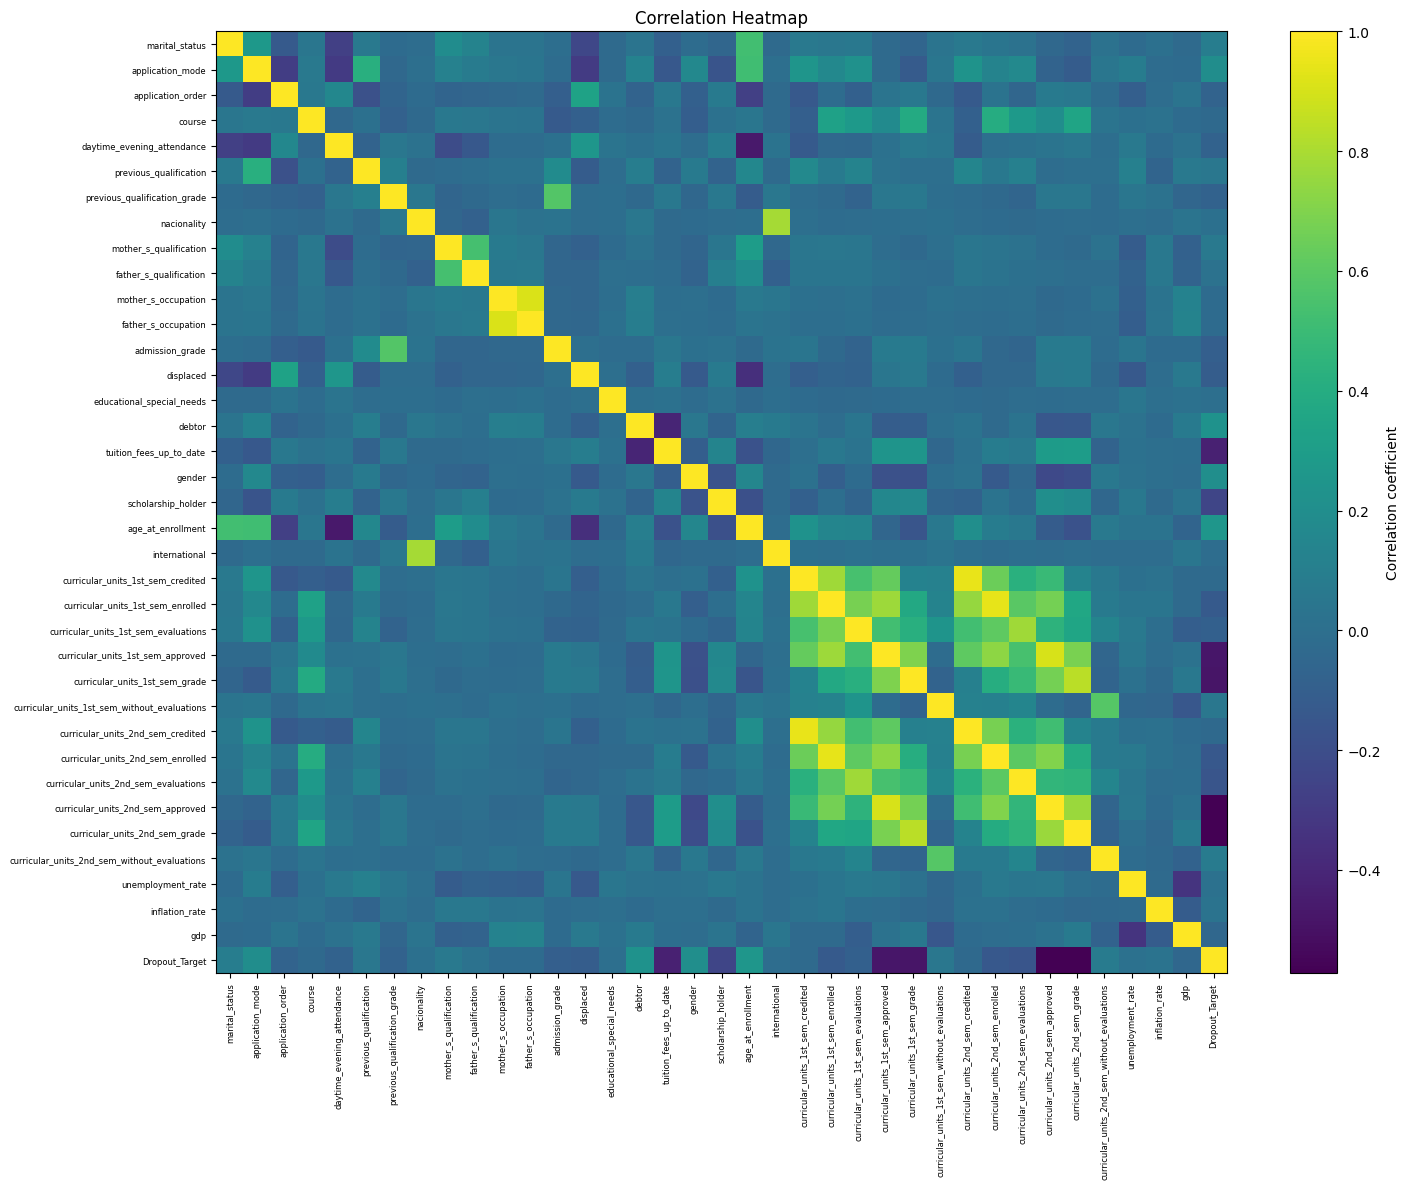


Variables most strongly correlated with dropout:


,Correlation with dropout
curricular_units_2nd_sem_grade,-0.572
curricular_units_2nd_sem_approved,-0.570
curricular_units_1st_sem_grade,-0.481
curricular_units_1st_sem_approved,-0.479
tuition_fees_up_to_date,-0.429
age_at_enrollment,0.254
scholarship_holder,-0.245
debtor,0.229
gender,0.204
application_mode,0.198


In [70]:
# Compares key academic variables across student outcomes and
# examines correlations among numeric variables.


# ------------------------------------------------------------
# Academic distributions by outcome
# ------------------------------------------------------------

academic_variables = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
]

for variable in academic_variables:

    if variable not in df.columns:
        continue

    summary = (
        df.groupby("Target")[variable]
          .agg(["mean", "median", "std", "count"])
          .round(3)
    )

    print(f"\nDistribution of {variable} by student outcome:")
    display(summary)


# ------------------------------------------------------------
# Correlation matrix for numeric variables
# ------------------------------------------------------------

numeric_data = df.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()


# ------------------------------------------------------------
# Plot and save the correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(15, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation coefficient")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=6
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=6
)

plt.title("Correlation Heatmap")
plt.tight_layout()

heatmap_path = (
    PATHS["figures"] / "correlation_heatmap.png"
)

plt.savefig(
    heatmap_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Variables most correlated with dropout
# ------------------------------------------------------------

if "Dropout_Target" in correlation_matrix.columns:

    dropout_correlations = (
        correlation_matrix["Dropout_Target"]
        .drop("Dropout_Target")
        .sort_values(
            key=np.abs,
            ascending=False
        )
        .head(20)
        .to_frame("Correlation with dropout")
    )

    print("\nVariables most strongly correlated with dropout:")
    display(dropout_correlations.round(3))

else:

    print(
        "\nDropout_Target is not available in the correlation matrix."
    )

## Cell 10 — Domain-informed feature engineering

In [71]:

# Creates interpretable academic, financial, and demographic
# features that may improve dropout prediction.


# ------------------------------------------------------------
# Create a working copy
# ------------------------------------------------------------

df_fe = df.copy()


# ------------------------------------------------------------
# Safe ratio function
# ------------------------------------------------------------
# Prevents division-by-zero and replaces undefined values with 0.

def ratio(numerator, denominator):
    return (
        numerator
        .div(denominator.replace(0, np.nan))
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )


# ------------------------------------------------------------
# Academic performance features
# ------------------------------------------------------------

df_fe["approval_rate_1st_sem"] = ratio(
    df_fe["curricular_units_1st_sem_approved"],
    df_fe["curricular_units_1st_sem_enrolled"]
)

df_fe["approval_rate_2nd_sem"] = ratio(
    df_fe["curricular_units_2nd_sem_approved"],
    df_fe["curricular_units_2nd_sem_enrolled"]
)

df_fe["approval_rate_change"] = (
    df_fe["approval_rate_2nd_sem"]
    - df_fe["approval_rate_1st_sem"]
)

df_fe["average_sem_grade"] = (
    df_fe["curricular_units_1st_sem_grade"]
    + df_fe["curricular_units_2nd_sem_grade"]
) / 2

df_fe["grade_change"] = (
    df_fe["curricular_units_2nd_sem_grade"]
    - df_fe["curricular_units_1st_sem_grade"]
)


# ------------------------------------------------------------
# Academic workload and completion features
# ------------------------------------------------------------

df_fe["total_enrolled_units"] = (
    df_fe["curricular_units_1st_sem_enrolled"]
    + df_fe["curricular_units_2nd_sem_enrolled"]
)

df_fe["total_approved_units"] = (
    df_fe["curricular_units_1st_sem_approved"]
    + df_fe["curricular_units_2nd_sem_approved"]
)

df_fe["overall_approval_rate"] = ratio(
    df_fe["total_approved_units"],
    df_fe["total_enrolled_units"]
)


# ------------------------------------------------------------
# Risk indicators
# ------------------------------------------------------------

df_fe["financial_risk_flag"] = (
    (df_fe["debtor"] == 1)
    | (df_fe["tuition_fees_up_to_date"] == 0)
).astype(int)

df_fe["academic_disengagement_flag"] = (
    (df_fe["curricular_units_1st_sem_approved"] == 0)
    | (df_fe["curricular_units_2nd_sem_approved"] == 0)
).astype(int)


# ------------------------------------------------------------
# Age grouping
# ------------------------------------------------------------

df_fe["age_group"] = pd.cut(
    df_fe["age_at_enrollment"],
    bins=[0, 20, 25, 35, 100],
    labels=["<=20", "21-25", "26-35", "36+"],
    include_lowest=True
).astype(str)


# ------------------------------------------------------------
# Confirm the engineered dataset
# ------------------------------------------------------------

new_features = [
    "approval_rate_1st_sem",
    "approval_rate_2nd_sem",
    "approval_rate_change",
    "average_sem_grade",
    "grade_change",
    "total_enrolled_units",
    "total_approved_units",
    "overall_approval_rate",
    "financial_risk_flag",
    "academic_disengagement_flag",
    "age_group"
]

print(f"Original dataset shape: {df.shape}")
print(f"Engineered dataset shape: {df_fe.shape}")
print(f"New features created: {len(new_features)}")

display(df_fe[new_features].head())


Original dataset shape: (4424, 38)
Engineered dataset shape: (4424, 49)
New features created: 11


,approval_rate_1st_sem,approval_rate_2nd_sem,approval_rate_change,average_sem_grade,grade_change,total_enrolled_units,total_approved_units,overall_approval_rate,financial_risk_flag,academic_disengagement_flag,age_group
0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0,1,<=20
1,1.000000,1.000000,0.000000,13.833333,-0.333333,12,12,1.000000,1,0,<=20
2,0.000000,0.000000,0.000000,0.000000,0.000000,12,0,0.000000,1,1,<=20
3,1.000000,0.833333,-0.166667,12.914286,-1.028571,12,11,0.916667,0,0,<=20
4,0.833333,1.000000,0.166667,12.666667,0.666667,12,11,0.916667,0,0,36+


## Cell 11 — Leakage-aware prediction horizons and domain feature types

In [72]:

# Defines feature sets for admission, first-semester, and
# second-semester prediction while preventing future-data leakage.


# ------------------------------------------------------------
# Exclude target variables from all predictor sets
# ------------------------------------------------------------

exclude = [
    "target",
    "Dropout_Target"
]


# ------------------------------------------------------------
# Identify semester-based variables
# ------------------------------------------------------------

second_semester_features = (
    [column for column in df_fe.columns if "2nd_sem" in column]
    + [
        "approval_rate_2nd_sem",
        "approval_rate_change",
        "average_sem_grade",
        "grade_change",
        "total_enrolled_units",
        "total_approved_units",
        "overall_approval_rate",
        "academic_disengagement_flag"
    ]
)

first_semester_features = (
    [column for column in df_fe.columns if "1st_sem" in column]
    + [
        "approval_rate_1st_sem"
    ]
)


# Remove duplicates while preserving order
first_semester_features = list(
    dict.fromkeys(first_semester_features)
)

second_semester_features = list(
    dict.fromkeys(second_semester_features)
)


# ------------------------------------------------------------
# Define leakage-aware prediction horizons
# ------------------------------------------------------------

FEATURE_SETS = {
    "Admission-only": [
        column
        for column in df_fe.columns
        if column not in (
            exclude
            + first_semester_features
            + second_semester_features
        )
    ],

    "After first semester": [
        column
        for column in df_fe.columns
        if column not in (
            exclude
            + second_semester_features
        )
    ],

    "After second semester": [
        column
        for column in df_fe.columns
        if column not in exclude
    ]
}


# ============================================================
# DOMAIN-BASED FEATURE TYPES
# ============================================================
# Nominal variables are one-hot encoded, while remaining
# predictors are treated as numeric.


NOMINAL = [
    "marital_status",
    "application_mode",
    "application_order",
    "course",
    "daytime_evening_attendance",
    "previous_qualification",
    "nacionality",
    "mother_s_qualification",
    "father_s_qualification",
    "mother_s_occupation",
    "father_s_occupation",
    "displaced",
    "educational_special_needs",
    "debtor",
    "tuition_fees_up_to_date",
    "gender",
    "scholarship_holder",
    "international",
    "age_group",
    "financial_risk_flag",
    "academic_disengagement_flag"
]


# ------------------------------------------------------------
# Separate numeric and categorical predictors
# ------------------------------------------------------------

def feature_types(X):

    categorical_features = [
        column
        for column in NOMINAL
        if column in X.columns
    ]

    numeric_features = [
        column
        for column in X.columns
        if column not in categorical_features
    ]

    return numeric_features, categorical_features


# ------------------------------------------------------------
# Build the preprocessing pipeline
# ------------------------------------------------------------

def preprocessor_for(X):

    numeric_features, categorical_features = feature_types(X)

    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ])

    return (
        preprocessor,
        numeric_features,
        categorical_features
    )


# ------------------------------------------------------------
# Display feature counts by prediction horizon
# ------------------------------------------------------------

print("Leakage-aware prediction horizons:")

for horizon, features in FEATURE_SETS.items():

    X_horizon = df_fe[features]

    numeric_features, categorical_features = (
        feature_types(X_horizon)
    )

    print(
        f"{horizon}: "
        f"{len(features)} predictors "
        f"({len(numeric_features)} numeric, "
        f"{len(categorical_features)} categorical)"
    )


Leakage-aware prediction horizons:
Admission-only: 26 predictors (6 numeric, 20 categorical)
After first semester: 33 predictors (13 numeric, 20 categorical)
After second semester: 47 predictors (26 numeric, 21 categorical)


## Cell 12 — Stratified train/test split

In [73]:

# Splits the dataset into training and testing sets while
# preserving the original dropout-class distribution.


# ------------------------------------------------------------
# Define the target variable
# ------------------------------------------------------------

y = df_fe["Dropout_Target"]


# ------------------------------------------------------------
# Perform a stratified train/test split
# ------------------------------------------------------------
# 80% of the data is used for model training and cross-validation,
# while 20% is reserved for final model evaluation.

train_idx, test_idx = train_test_split(
    np.arange(len(df_fe)),
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# Create training and testing target sets
# ------------------------------------------------------------

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


# ------------------------------------------------------------
# Display the split summary
# ------------------------------------------------------------

print(f"Training samples: {len(train_idx):,}")
print(f"Testing samples: {len(test_idx):,}")

print("\nTraining set class distribution:")
display(
    (
        y_train.value_counts(normalize=True)
        .rename("Proportion")
        .mul(100)
        .round(2)
        .rename_axis("Dropout_Target")
        .reset_index()
    )
)

print("\nTesting set class distribution:")
display(
    (
        y_test.value_counts(normalize=True)
        .rename("Proportion")
        .mul(100)
        .round(2)
        .rename_axis("Dropout_Target")
        .reset_index()
    )
)

Training samples: 3,539
Testing samples: 885

Training set class distribution:


,Dropout_Target,Proportion
0,0,67.87
1,1,32.13



Testing set class distribution:


,Dropout_Target,Proportion
0,0,67.91
1,1,32.09


## Cell 13 — Feature selection and PCA

Top 30 features selected using mutual information:


,Feature,Mutual information,Selected
12,approval_rate_1st_sem,0.1828,True
6,curricular_units_1st_sem_approved,0.1688,True
7,curricular_units_1st_sem_grade,0.1443,True
237,tuition_fees_up_to_date_0,0.0881,True
238,tuition_fees_up_to_date_1,0.0709,True
250,financial_risk_flag_1,0.0680,True
249,financial_risk_flag_0,0.0652,True
2,age_at_enrollment,0.0585,True
5,curricular_units_1st_sem_evaluations,0.0585,True
241,scholarship_holder_0,0.0431,True


Processed features: 251
PCA components retained: 56
Explained variance retained: 0.9523


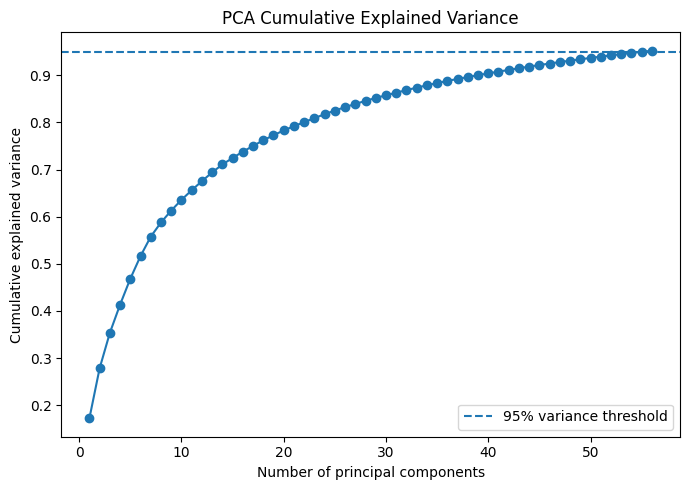

In [74]:

# Evaluates predictor relevance using mutual information and
# estimates dimensionality using principal component analysis.


# ------------------------------------------------------------
# Prepare first-semester training features
# ------------------------------------------------------------

X_fs = df_fe[FEATURE_SETS["After first semester"]]
X_train_fs = X_fs.iloc[train_idx]


# ------------------------------------------------------------
# Preprocess the training data
# ------------------------------------------------------------

pre_fs, num_fs, cat_fs = preprocessor_for(X_train_fs)

X_train_processed = pre_fs.fit_transform(X_train_fs)

X_train_dense = (
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)


# ------------------------------------------------------------
# Recover processed feature names
# ------------------------------------------------------------

feature_names = (
    list(num_fs)
    + list(
        pre_fs.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(cat_fs)
    )
)


# ------------------------------------------------------------
# Mutual-information feature selection
# ------------------------------------------------------------

k_selected = min(30, X_train_dense.shape[1])

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k_selected
)

selector.fit(
    X_train_dense,
    y_train
)

mutual_information = pd.DataFrame({
    "Feature": feature_names,
    "Mutual information": selector.scores_,
    "Selected": selector.get_support()
}).sort_values(
    "Mutual information",
    ascending=False
)

print(
    f"Top {k_selected} features selected using mutual information:"
)

display(
    mutual_information.head(k_selected).round(4)
)

mutual_information.to_csv(
    PATHS["tables"] / "mutual_information.csv",
    index=False
)


# ------------------------------------------------------------
# Principal component analysis
# ------------------------------------------------------------
# Retain enough components to explain at least 95% of variance.

pca = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE
)

pca.fit(X_train_dense)

print(f"Processed features: {X_train_dense.shape[1]}")
print(f"PCA components retained: {pca.n_components_}")
print(
    f"Explained variance retained: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)


# ------------------------------------------------------------
# Plot cumulative explained variance
# ------------------------------------------------------------

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance threshold"
)

plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()

pca_figure_path = PATHS["figures"] / "pca.png"

plt.savefig(
    pca_figure_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()

## Cell 14 — Define models and tuning grids

In [75]:

# Defines the classification algorithms, hyperparameter search
# spaces, and stratified cross-validation strategy.


# ------------------------------------------------------------
# Candidate models and tuning parameters
# ------------------------------------------------------------

SPECS = {

    "Logistic Regression": (
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        {
            "classifier__C": [0.01, 0.1, 1, 10]
        }
    ),

    "Decision Tree": (
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        {
            "classifier__max_depth": [3, 5, 8, 12, None],
            "classifier__min_samples_leaf": [1, 5, 10, 20]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        {
            "classifier__n_estimators": [300, 600],
            "classifier__max_depth": [8, 12, None],
            "classifier__min_samples_leaf": [1, 5, 10]
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),
        {
            "classifier__n_estimators": [100, 200],
            "classifier__learning_rate": [0.03, 0.1],
            "classifier__max_depth": [2, 3]
        }
    ),

    "SVM": (
        SVC(
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        {
            "classifier__C": [0.5, 1, 2],
            "classifier__gamma": ["scale", "auto"]
        }
    )
}


# ------------------------------------------------------------
# Stratified cross-validation
# ------------------------------------------------------------
# Preserves the dropout-class distribution across five folds.

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# Display model-search summary
# ------------------------------------------------------------

print(f"Candidate models: {len(SPECS)}")
print(f"Cross-validation folds: {CV.n_splits}")

for model_name, (_, parameter_grid) in SPECS.items():

    combinations = int(
        np.prod([
            len(values)
            for values in parameter_grid.values()
        ])
    )

    print(
        f"{model_name}: "
        f"{combinations} hyperparameter combinations"
    )

Candidate models: 5
Cross-validation folds: 5
Logistic Regression: 4 hyperparameter combinations
Decision Tree: 20 hyperparameter combinations
Random Forest: 18 hyperparameter combinations
Gradient Boosting: 8 hyperparameter combinations
SVM: 6 hyperparameter combinations


## Cell 15 — Train and compare all models across prediction horizons

In [76]:

# Tunes each model using cross-validation and evaluates the best
# version on the held-out test set for every prediction horizon.


# ------------------------------------------------------------
# Store model results and fitted estimators
# ------------------------------------------------------------

results = []
trained = {}


# ------------------------------------------------------------
# Train models for each prediction horizon
# ------------------------------------------------------------

for horizon, feature_columns in FEATURE_SETS.items():

    X = df_fe[feature_columns]

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    preprocessor, _, _ = preprocessor_for(X_train)

    print(f"\nTraining models for: {horizon}")

    for model_name, (model, parameter_grid) in SPECS.items():

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", clone(model))
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=parameter_grid,
            scoring="f1",
            cv=CV,
            n_jobs=-1,
            return_train_score=True
        )

        grid_search.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # Test-set predictions at the default 0.50 threshold
        # ----------------------------------------------------

        probabilities = (
            grid_search.best_estimator_
            .predict_proba(X_test)[:, 1]
        )

        predictions = (
            probabilities >= 0.50
        ).astype(int)


        # ----------------------------------------------------
        # Retrieve the best cross-validation result
        # ----------------------------------------------------

        best_cv_row = pd.DataFrame(
            grid_search.cv_results_
        ).iloc[grid_search.best_index_]


        # ----------------------------------------------------
        # Record performance metrics
        # ----------------------------------------------------

        result_record = {
            "Horizon": horizon,
            "Model": model_name,
            "CV F1": grid_search.best_score_,
            "Overfit gap": (
                best_cv_row["mean_train_score"]
                - best_cv_row["mean_test_score"]
            ),
            "Accuracy": accuracy_score(
                y_test,
                predictions
            ),
            "Balanced Accuracy": balanced_accuracy_score(
                y_test,
                predictions
            ),
            "Precision": precision_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "ROC-AUC": roc_auc_score(
                y_test,
                probabilities
            ),
            "PR-AUC": average_precision_score(
                y_test,
                probabilities
            ),
            "Brier": brier_score_loss(
                y_test,
                probabilities
            ),
            "Parameters": grid_search.best_params_
        }

        results.append(result_record)


        # ----------------------------------------------------
        # Save the fitted best model and its feature set
        # ----------------------------------------------------

        trained[(horizon, model_name)] = {
            "model": grid_search.best_estimator_,
            "features": feature_columns
        }

        print(
            f"  {model_name}: "
            f"CV F1 = {grid_search.best_score_:.3f}, "
            f"Test F1 = {result_record['F1']:.3f}"
        )


# ------------------------------------------------------------
# Create and save the comparison table
# ------------------------------------------------------------

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["Horizon", "F1"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print("\nModel comparison across prediction horizons:")
display(results_df.round(4))

results_path = (
    PATHS["tables"] / "model_comparison.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(f"\nModel comparison saved to:\n{results_path.resolve()}")


Training models for: Admission-only
  Logistic Regression: CV F1 = 0.651, Test F1 = 0.651
  Decision Tree: CV F1 = 0.609, Test F1 = 0.637
  Random Forest: CV F1 = 0.636, Test F1 = 0.638
  Gradient Boosting: CV F1 = 0.611, Test F1 = 0.614
  SVM: CV F1 = 0.646, Test F1 = 0.658

Training models for: After first semester
  Logistic Regression: CV F1 = 0.764, Test F1 = 0.790
  Decision Tree: CV F1 = 0.743, Test F1 = 0.761
  Random Forest: CV F1 = 0.765, Test F1 = 0.776
  Gradient Boosting: CV F1 = 0.763, Test F1 = 0.778
  SVM: CV F1 = 0.768, Test F1 = 0.766

Training models for: After second semester
  Logistic Regression: CV F1 = 0.785, Test F1 = 0.823
  Decision Tree: CV F1 = 0.775, Test F1 = 0.810
  Random Forest: CV F1 = 0.789, Test F1 = 0.814
  Gradient Boosting: CV F1 = 0.799, Test F1 = 0.811
  SVM: CV F1 = 0.792, Test F1 = 0.817

Model comparison across prediction horizons:


,Horizon,Model,CV F1,Overfit gap,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Parameters
0,Admission-only,SVM,0.6463,0.1014,0.8023,0.7467,0.7401,0.5915,0.6575,0.8355,0.7511,0.1436,"{'classifier__C': 1, 'classifier__gamma': 'sca..."
1,Admission-only,Logistic Regression,0.6506,0.0478,0.7525,0.7435,0.5948,0.7183,0.6507,0.8283,0.7412,0.1643,{'classifier__C': 10}
2,Admission-only,Random Forest,0.6355,0.0798,0.7605,0.7336,0.6192,0.6585,0.6382,0.8232,0.7431,0.1650,"{'classifier__max_depth': 12, 'classifier__min..."
3,Admission-only,Decision Tree,0.6092,0.0195,0.7040,0.7319,0.5251,0.8099,0.6371,0.8042,0.6751,0.1756,"{'classifier__max_depth': 5, 'classifier__min_..."
4,Admission-only,Gradient Boosting,0.6109,0.1311,0.7910,0.7189,0.7538,0.5176,0.6138,0.8365,0.7562,0.1432,"{'classifier__learning_rate': 0.1, 'classifier..."
5,After first semester,Logistic Regression,0.7640,0.0297,0.8599,0.8495,0.7614,0.8204,0.7898,0.9134,0.8764,0.1067,{'classifier__C': 1}
6,After first semester,Gradient Boosting,0.7625,0.0924,0.8678,0.8293,0.8436,0.7218,0.7780,0.9141,0.8802,0.0975,"{'classifier__learning_rate': 0.1, 'classifier..."
7,After first semester,Random Forest,0.7649,0.1486,0.8576,0.8339,0.7842,0.7676,0.7758,0.9101,0.8756,0.1094,"{'classifier__max_depth': 12, 'classifier__min..."
8,After first semester,SVM,0.7676,0.1128,0.8599,0.8216,0.8252,0.7148,0.7660,0.9120,0.8723,0.1003,"{'classifier__C': 2, 'classifier__gamma': 'sca..."
9,After first semester,Decision Tree,0.7426,0.0364,0.8418,0.8269,0.7384,0.7852,0.7611,0.8845,0.7966,0.1245,"{'classifier__max_depth': 5, 'classifier__min_..."



Model comparison saved to:
/content/reports/tables/model_comparison.csv


## Cell 16 — Select operational model, calibrate probabilities, and optimize threshold

In [77]:

# Selects the best first-semester model, checks probability
# calibration, and identifies an operating threshold with
# recall of at least 85% when feasible.


# ------------------------------------------------------------
# Select the operational prediction horizon
# ------------------------------------------------------------

OP_HORIZON = "After first semester"

operational_results = (
    results_df[
        results_df["Horizon"] == OP_HORIZON
    ]
    .sort_values(
        ["F1", "Recall", "PR-AUC"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

print(f"Candidate models for: {OP_HORIZON}")
display(operational_results.round(4))


# ------------------------------------------------------------
# Select the highest-ranked model
# ------------------------------------------------------------

BEST_NAME = operational_results.iloc[0]["Model"]

base_model = trained[
    (OP_HORIZON, BEST_NAME)
]["model"]

features = trained[
    (OP_HORIZON, BEST_NAME)
]["features"]

print(f"Selected operational model: {BEST_NAME}")


# ------------------------------------------------------------
# Prepare operational training and test data
# ------------------------------------------------------------

X = df_fe[features]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]


# ------------------------------------------------------------
# Calibrate predicted probabilities
# ------------------------------------------------------------
# Sigmoid calibration is retained only when it improves the
# Brier score on the held-out test set.

calibrated_model = CalibratedClassifierCV(
    estimator=clone(base_model),
    method="sigmoid",
    cv=5
)

calibrated_model.fit(
    X_train,
    y_train
)

base_probabilities = (
    base_model.predict_proba(X_test)[:, 1]
)

calibrated_probabilities = (
    calibrated_model.predict_proba(X_test)[:, 1]
)

base_brier = brier_score_loss(
    y_test,
    base_probabilities
)

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_probabilities
)

if calibrated_brier < base_brier:

    final_model = calibrated_model
    final_probabilities = calibrated_probabilities
    calibration_status = "Calibrated model selected"

else:

    final_model = base_model
    final_probabilities = base_probabilities
    calibration_status = "Base model retained"

print(f"Base-model Brier score: {base_brier:.4f}")
print(f"Calibrated Brier score: {calibrated_brier:.4f}")
print(calibration_status)


# ------------------------------------------------------------
# Evaluate candidate classification thresholds
# ------------------------------------------------------------

threshold_records = []

for threshold in np.linspace(0.10, 0.90, 161):

    predictions = (
        final_probabilities >= threshold
    ).astype(int)

    threshold_records.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "Alerts": int(predictions.sum())
    })

threshold_analysis = pd.DataFrame(
    threshold_records
)


# ------------------------------------------------------------
# Select the operational threshold
# ------------------------------------------------------------
# Prefer thresholds with recall of at least 85%. Among eligible
# thresholds, select the highest F1 and then highest precision.

eligible_thresholds = threshold_analysis[
    threshold_analysis["Recall"] >= 0.85
]

selection_pool = (
    eligible_thresholds
    if not eligible_thresholds.empty
    else threshold_analysis
)

selected_threshold = (
    selection_pool
    .sort_values(
        ["F1", "Precision"],
        ascending=[False, False]
    )
    .iloc[0]
)

THRESHOLD = float(
    selected_threshold["Threshold"]
)

final_predictions = (
    final_probabilities >= THRESHOLD
).astype(int)


# ------------------------------------------------------------
# Display and save final outputs
# ------------------------------------------------------------

print(f"\nSelected threshold: {THRESHOLD:.3f}")
display(
    selected_threshold
    .to_frame("Selected value")
    .round(4)
)

model_path = (
    PATHS["models"] / "final_model.pkl"
)

threshold_path = (
    PATHS["tables"] / "threshold_analysis.csv"
)

joblib.dump(
    final_model,
    model_path
)

threshold_analysis.to_csv(
    threshold_path,
    index=False
)

print(f"\nFinal model saved to:\n{model_path.resolve()}")
print(f"\nThreshold analysis saved to:\n{threshold_path.resolve()}")

Candidate models for: After first semester


,Horizon,Model,CV F1,Overfit gap,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Parameters
0,After first semester,Logistic Regression,0.7640,0.0297,0.8599,0.8495,0.7614,0.8204,0.7898,0.9134,0.8764,0.1067,{'classifier__C': 1}
1,After first semester,Gradient Boosting,0.7625,0.0924,0.8678,0.8293,0.8436,0.7218,0.7780,0.9141,0.8802,0.0975,"{'classifier__learning_rate': 0.1, 'classifier..."
2,After first semester,Random Forest,0.7649,0.1486,0.8576,0.8339,0.7842,0.7676,0.7758,0.9101,0.8756,0.1094,"{'classifier__max_depth': 12, 'classifier__min..."
3,After first semester,SVM,0.7676,0.1128,0.8599,0.8216,0.8252,0.7148,0.7660,0.9120,0.8723,0.1003,"{'classifier__C': 2, 'classifier__gamma': 'sca..."
4,After first semester,Decision Tree,0.7426,0.0364,0.8418,0.8269,0.7384,0.7852,0.7611,0.8845,0.7966,0.1245,"{'classifier__max_depth': 5, 'classifier__min_..."


Selected operational model: Logistic Regression
Base-model Brier score: 0.1067
Calibrated Brier score: 0.0978
Calibrated model selected

Selected threshold: 0.265


,Selected value
Threshold,0.2650
Precision,0.7139
Recall,0.8521
F1,0.7769
Balanced Accuracy,0.8454
Alerts,339.0000



Final model saved to:
/content/models/final_model.pkl

Threshold analysis saved to:
/content/reports/tables/threshold_analysis.csv


## Cell 17 — Final evaluation, calibration, ROC, PR, and confusion matrix

Final model performance:


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,Threshold
0,0.8429,0.8454,0.7139,0.8521,0.7769,0.9133,0.8769,0.0978,0.265



Classification report:
              precision    recall  f1-score   support

 Non-Dropout       0.92      0.84      0.88       601
     Dropout       0.71      0.85      0.78       284

    accuracy                           0.84       885
   macro avg       0.82      0.85      0.83       885
weighted avg       0.86      0.84      0.85       885

Confusion matrix:


,Predicted Non-Dropout,Predicted Dropout
Actual Non-Dropout,504,97
Actual Dropout,42,242


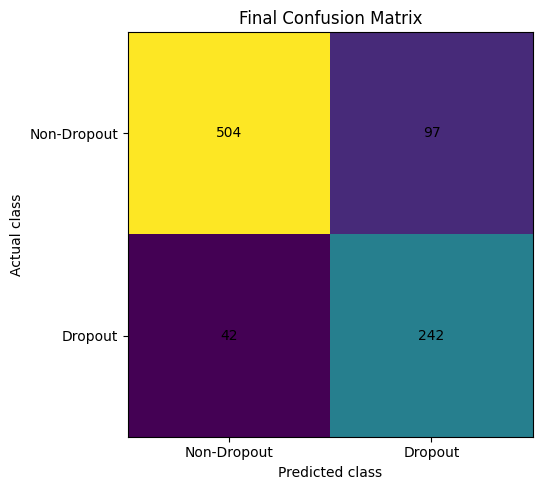

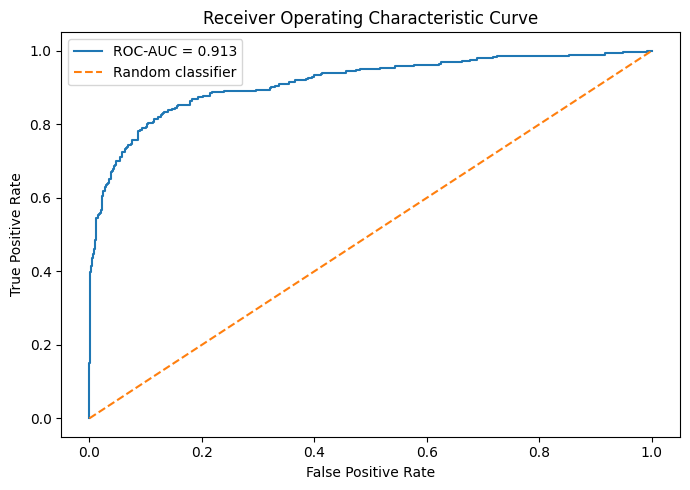

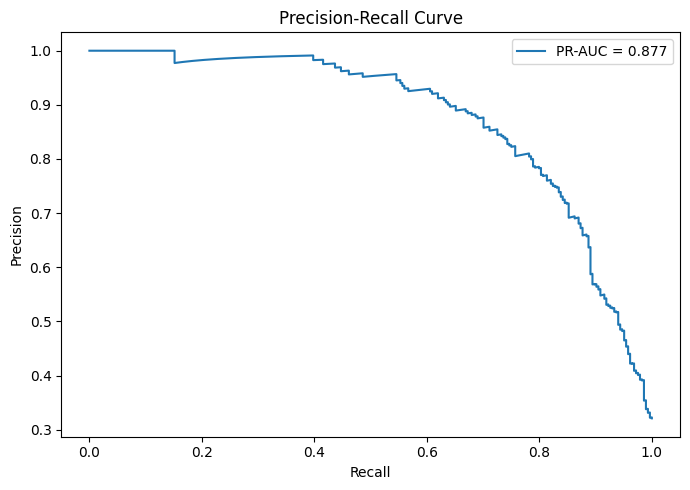


Evaluation outputs saved to:
/content/reports/figures/confusion_matrix.png
/content/reports/figures/roc_curve.png
/content/reports/figures/precision_recall_curve.png
/content/reports/tables/final_model_metrics.csv


In [78]:

# Reports final classification metrics and visualizes the
# confusion matrix, ROC curve, and precision-recall curve.


# ------------------------------------------------------------
# Calculate final test-set metrics
# ------------------------------------------------------------

final_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        final_predictions
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        final_predictions
    ),
    "Precision": precision_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        final_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_test,
        final_probabilities
    ),
    "Brier": brier_score_loss(
        y_test,
        final_probabilities
    ),
    "Threshold": THRESHOLD
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

print("Final model performance:")
display(final_metrics_df.round(4))


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification report:")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Non-Dropout",
            "Dropout"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

confusion = confusion_matrix(
    y_test,
    final_predictions
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "Actual Non-Dropout",
        "Actual Dropout"
    ],
    columns=[
        "Predicted Non-Dropout",
        "Predicted Dropout"
    ]
)

print("Confusion matrix:")
display(confusion_df)


# ------------------------------------------------------------
# Plot and save the confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(confusion)

plt.xticks(
    [0, 1],
    ["Non-Dropout", "Dropout"]
)

plt.yticks(
    [0, 1],
    ["Non-Dropout", "Dropout"]
)

for row in range(2):
    for column in range(2):
        plt.text(
            column,
            row,
            confusion[row, column],
            ha="center",
            va="center"
        )

plt.title("Final Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()

confusion_path = (
    PATHS["figures"] / "confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC-AUC = {final_metrics['ROC-AUC']:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("Receiver Operating Characteristic Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

roc_path = (
    PATHS["figures"] / "roc_curve.png"
)

plt.savefig(
    roc_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Precision-recall curve
# ------------------------------------------------------------

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {final_metrics['PR-AUC']:.3f}"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()

pr_path = (
    PATHS["figures"] / "precision_recall_curve.png"
)

plt.savefig(
    pr_path,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Save final evaluation metrics
# ------------------------------------------------------------

metrics_path = (
    PATHS["tables"] / "final_model_metrics.csv"
)

final_metrics_df.to_csv(
    metrics_path,
    index=False
)

print("\nEvaluation outputs saved to:")
print(confusion_path.resolve())
print(roc_path.resolve())
print(pr_path.resolve())
print(metrics_path.resolve())

## Cell 18 — Multiclass sensitivity analysis

In [79]:

# Tests whether the first-semester model can distinguish among
# Dropout, Enrolled, and Graduate outcomes.


# ------------------------------------------------------------
# Encode the three outcome classes
# ------------------------------------------------------------

multiclass_target = df_fe["target"].map({
    "Dropout": 0,
    "Enrolled": 1,
    "Graduate": 2
})


# ------------------------------------------------------------
# Prepare first-semester predictors
# ------------------------------------------------------------

X_multiclass = df_fe[
    FEATURE_SETS["After first semester"]
]

X_train_multiclass = X_multiclass.iloc[train_idx]
X_test_multiclass = X_multiclass.iloc[test_idx]

y_train_multiclass = multiclass_target.iloc[train_idx]
y_test_multiclass = multiclass_target.iloc[test_idx]


# ------------------------------------------------------------
# Build the preprocessing and classification pipeline
# ------------------------------------------------------------

preprocessor, _, _ = preprocessor_for(
    X_train_multiclass
)

multiclass_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])


# ------------------------------------------------------------
# Tune logistic regression using macro F1
# ------------------------------------------------------------
# Macro F1 gives equal importance to all three outcome classes.

multiclass_search = GridSearchCV(
    estimator=multiclass_pipeline,
    param_grid={
        "classifier__C": [0.01, 0.1, 1, 10]
    },
    scoring="f1_macro",
    cv=CV,
    n_jobs=-1
)

multiclass_search.fit(
    X_train_multiclass,
    y_train_multiclass
)


# ------------------------------------------------------------
# Generate multiclass predictions
# ------------------------------------------------------------

multiclass_predictions = (
    multiclass_search.predict(
        X_test_multiclass
    )
)

multiclass_probabilities = (
    multiclass_search.predict_proba(
        X_test_multiclass
    )
)


# ------------------------------------------------------------
# Evaluate multiclass performance
# ------------------------------------------------------------

macro_f1 = f1_score(
    y_test_multiclass,
    multiclass_predictions,
    average="macro"
)

macro_ovr_auc = roc_auc_score(
    y_test_multiclass,
    multiclass_probabilities,
    multi_class="ovr",
    average="macro"
)

print(
    f"Best parameters: "
    f"{multiclass_search.best_params_}"
)

print(
    f"Cross-validation macro F1: "
    f"{multiclass_search.best_score_:.4f}"
)

print("\nMulticlass classification report:")

print(
    classification_report(
        y_test_multiclass,
        multiclass_predictions,
        labels=[0, 1, 2],
        target_names=[
            "Dropout",
            "Enrolled",
            "Graduate"
        ],
        zero_division=0
    )
)

print(f"Test macro F1: {macro_f1:.4f}")
print(f"Test one-vs-rest macro AUC: {macro_ovr_auc:.4f}")


Best parameters: {'classifier__C': 10}
Cross-validation macro F1: 0.6664

Multiclass classification report:
              precision    recall  f1-score   support

     Dropout       0.82      0.73      0.77       284
    Enrolled       0.44      0.58      0.50       162
    Graduate       0.84      0.80      0.82       439

    accuracy                           0.74       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.74      0.75       885

Test macro F1: 0.6975
Test one-vs-rest macro AUC: 0.8688


## Cell 19 — Explainability: coefficients, odds ratios, and permutation importance

In [80]:

# Interprets the selected operational model using model
# coefficients (when available) and permutation importance.


# ------------------------------------------------------------
# Coefficients and odds ratios
# ------------------------------------------------------------
# Available for linear models such as Logistic Regression.

classifier = base_model.named_steps["classifier"]

if hasattr(classifier, "coef_"):

    preprocessor = base_model.named_steps["preprocessor"]

    numeric_features, categorical_features = feature_types(X_train)

    feature_names = (
        list(numeric_features)
        + list(
            preprocessor.named_transformers_["cat"]
            .named_steps["onehot"]
            .get_feature_names_out(categorical_features)
        )
    )

    coefficients = classifier.coef_[0]

    coefficient_table = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Odds Ratio": np.exp(coefficients),
        "Absolute": np.abs(coefficients)
    }).sort_values(
        "Absolute",
        ascending=False
    )

    print("Top model coefficients:")
    display(
        coefficient_table.head(30).round(4)
    )

    coefficient_path = (
        PATHS["tables"] /
        "coefficients_odds_ratios.csv"
    )

    coefficient_table.to_csv(
        coefficient_path,
        index=False
    )

    print(f"Coefficient table saved to:\n{coefficient_path.resolve()}")

else:

    print(
        "Coefficient-based interpretation is not "
        "available for this model."
    )


# ------------------------------------------------------------
# Permutation feature importance
# ------------------------------------------------------------
# Measures the reduction in F1 score after randomly shuffling
# each predictor.

permutation = permutation_importance(
    estimator=base_model,
    X=X_test,
    y=y_test,
    scoring="f1",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation.importances_mean,
    "SD": permutation.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

print("\nTop permutation importance rankings:")

display(
    permutation_table.head(20).round(4)
)

permutation_path = (
    PATHS["tables"] /
    "permutation_importance.csv"
)

permutation_table.to_csv(
    permutation_path,
    index=False
)

print(f"Permutation importance saved to:\n{permutation_path.resolve()}")

Top model coefficients:


,Feature,Coefficient,Odds Ratio,Absolute
6,curricular_units_1st_sem_approved,-2.0459,0.1293,2.0459
184,mother_s_occupation_191,-1.7961,0.1659,1.7961
157,mother_s_occupation_0,1.4032,4.0681,1.4032
139,father_s_qualification_22,1.3098,3.7054,1.3098
102,mother_s_qualification_4,-1.3056,0.2710,1.3056
60,course_9853,1.2974,3.6598,1.2974
199,father_s_occupation_90,1.2859,3.6179,1.2859
46,course_171,-1.2619,0.2831,1.2619
237,tuition_fees_up_to_date_0,1.1739,3.2345,1.1739
98,nacionality_109,1.1734,3.2329,1.1734


Coefficient table saved to:
/content/reports/tables/coefficients_odds_ratios.csv

Top permutation importance rankings:


,Feature,Importance,SD
24,curricular_units_1st_sem_approved,0.2533,0.0158
16,tuition_fees_up_to_date,0.0789,0.0085
22,curricular_units_1st_sem_enrolled,0.0589,0.0095
21,curricular_units_1st_sem_credited,0.0346,0.0047
27,unemployment_rate,0.0244,0.0088
3,course,0.0207,0.0078
32,age_group,0.0204,0.0062
1,application_mode,0.0159,0.0075
11,father_s_occupation,0.0147,0.0058
30,approval_rate_1st_sem,0.0119,0.0044


Permutation importance saved to:
/content/reports/tables/permutation_importance.csv


## Cell 20 — SHAP and partial dependence

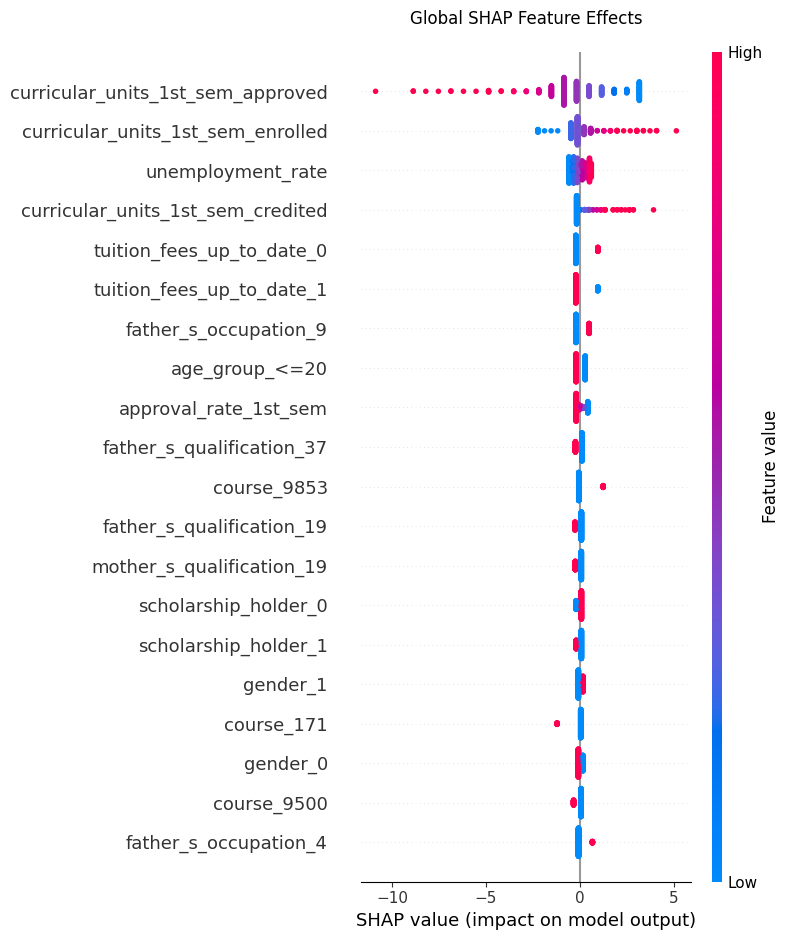

SHAP summary plot saved to: /content/reports/figures/shap_summary.png

Selected student information
----------------------------
Original dataset index: 3533
Test-set position: 90
Predicted dropout probability: 1.0
Actual outcome: Dropout


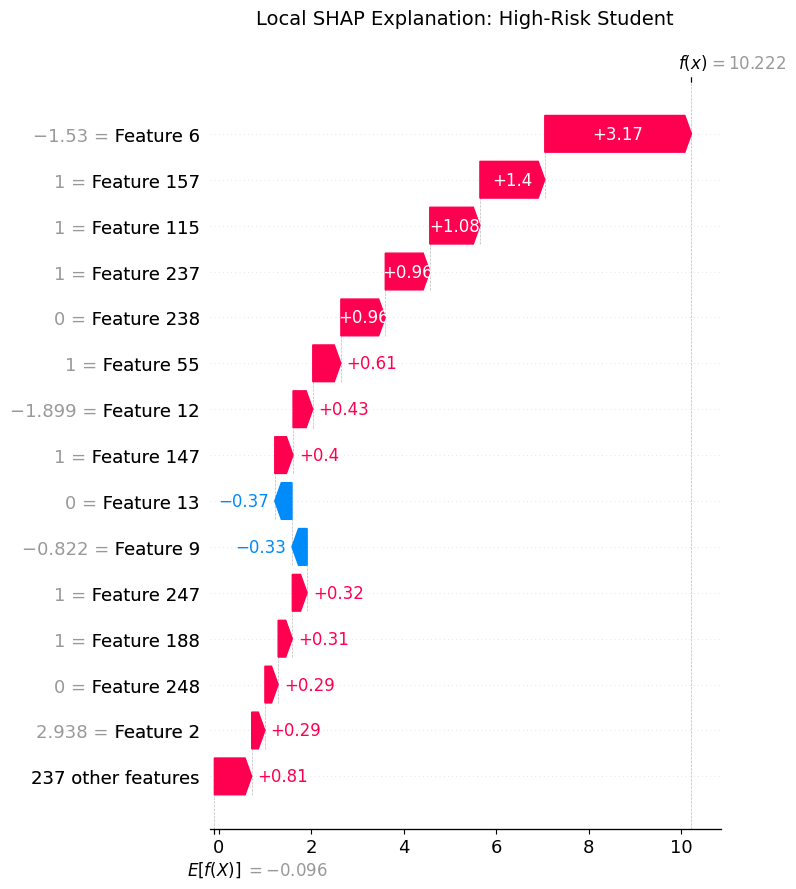

SHAP waterfall plot saved to: /content/reports/figures/shap_waterfall_high_risk_student.png


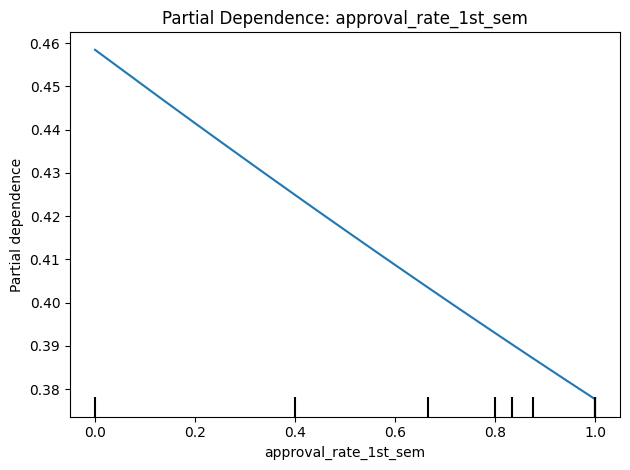

Partial dependence plot saved to: /content/reports/figures/partial_dependence_approval_rate_1st_sem.png


In [81]:

# Provides global and local explanations for the selected
# operational model and examines selected predictor effects.


# ------------------------------------------------------------
# Extract the fitted preprocessing and classifier components
# ------------------------------------------------------------

preprocessor = base_model.named_steps["preprocessor"]
classifier = base_model.named_steps["classifier"]

numeric_features, categorical_features = feature_types(X_train)

processed_feature_names = (
    list(numeric_features)
    + list(
        preprocessor.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_features)
    )
)


# ============================================================
# GLOBAL SHAP ANALYSIS
# ============================================================

if SHAP_AVAILABLE and hasattr(classifier, "coef_"):

    # Transform the training and test predictors using the
    # preprocessing fitted within the operational pipeline.

    X_train_transformed = preprocessor.transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    X_train_dense = (
        X_train_transformed.toarray()
        if hasattr(X_train_transformed, "toarray")
        else X_train_transformed
    )

    X_test_dense = (
        X_test_transformed.toarray()
        if hasattr(X_test_transformed, "toarray")
        else X_test_transformed
    )


    # --------------------------------------------------------
    # Define SHAP background and explanation samples
    # --------------------------------------------------------

    background_size = min(
        500,
        len(X_train_dense)
    )

    explanation_size = min(
        300,
        len(X_test_dense)
    )

    shap_background = X_train_dense[
        :background_size
    ]

    shap_explanation_data = X_test_dense[
        :explanation_size
    ]


    # --------------------------------------------------------
    # Calculate SHAP values
    # --------------------------------------------------------

    shap_explainer = shap.LinearExplainer(
        classifier,
        shap.maskers.Independent(
            shap_background
        )
    )

    shap_values = shap_explainer(
        shap_explanation_data
    )


    # --------------------------------------------------------
    # Global SHAP summary plot
    # --------------------------------------------------------

    shap.summary_plot(
        shap_values,
        shap_explanation_data,
        feature_names=processed_feature_names,
        max_display=20,
        show=False
    )

    plt.title(
        "Global SHAP Feature Effects",
        pad=20
    )
    plt.tight_layout()

    shap_summary_path = (
        PATHS["figures"] /
        "shap_summary.png"
    )

    plt.savefig(
        shap_summary_path,
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "SHAP summary plot saved to:",
        shap_summary_path.resolve()
    )


    # ========================================================
    # LOCAL SHAP WATERFALL PLOT
    # ========================================================
    # Explain the student with the highest predicted dropout
    # probability among the observations included in SHAP.

    explained_test_data = X_test.iloc[
        :explanation_size
    ]

    local_probabilities = base_model.predict_proba(
        explained_test_data
    )[:, 1]

    student_position = int(
        np.argmax(local_probabilities)
    )

    student_dataset_index = (
        explained_test_data.index[
            student_position
        ]
    )

    actual_outcome = int(
        y_test.iloc[student_position]
    )

    print("\nSelected student information")
    print("----------------------------")
    print(
        "Original dataset index:",
        student_dataset_index
    )
    print(
        "Test-set position:",
        student_position
    )
    print(
        "Predicted dropout probability:",
        round(
            float(
                local_probabilities[
                    student_position
                ]
            ),
            4
        )
    )
    print(
        "Actual outcome:",
        "Dropout"
        if actual_outcome == 1
        else "Non-Dropout"
    )


    # --------------------------------------------------------
    # Generate local waterfall plot
    # --------------------------------------------------------

    shap.plots.waterfall(
        shap_values[student_position],
        max_display=15,
        show=False
    )

    plt.title(
        "Local SHAP Explanation: High-Risk Student",
        fontsize=14,
        pad=20
    )

    plt.tight_layout()

    waterfall_path = (
        PATHS["figures"] /
        "shap_waterfall_high_risk_student.png"
    )

    plt.savefig(
        waterfall_path,
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "SHAP waterfall plot saved to:",
        waterfall_path.resolve()
    )

else:

    if not SHAP_AVAILABLE:
        print(
            "SHAP analysis skipped because the "
            "SHAP package is unavailable."
        )
    else:
        print(
            "Linear SHAP analysis skipped because "
            "the selected classifier has no coefficients."
        )


# ============================================================
# PARTIAL DEPENDENCE ANALYSIS
# ============================================================
# Shows the average predicted response as selected predictors
# vary while other predictors are averaged over the test set.

candidate_pdp_features = [
    "Age at enrollment",
    "Admission grade",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "approval_rate_1st_sem"
]

available_pdp_features = [
    feature
    for feature in candidate_pdp_features
    if feature in X_test.columns
]

if available_pdp_features:

    for feature in available_pdp_features:

        PartialDependenceDisplay.from_estimator(
            estimator=base_model,
            X=X_test,
            features=[feature]
        )

        plt.title(
            f"Partial Dependence: {feature}"
        )
        plt.tight_layout()

        safe_feature_name = (
            feature.lower()
            .replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("/", "_")
        )

        pdp_path = (
            PATHS["figures"] /
            f"partial_dependence_{safe_feature_name}.png"
        )

        plt.savefig(
            pdp_path,
            dpi=250,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"Partial dependence plot saved to: "
            f"{pdp_path.resolve()}"
        )

else:

    print(
        "No specified partial-dependence features "
        "were found in the operational dataset."
    )

## Cell 21 — Fairness metrics and disparity summary

In [82]:

# Evaluates model performance across selected demographic and
# socioeconomic groups using group-level fairness indicators.


# ------------------------------------------------------------
# Prepare fairness evaluation dataset
# ------------------------------------------------------------

fairness_data = X_test.copy()

fairness_data["y_true"] = y_test.values
fairness_data["y_pred"] = final_predictions


# ------------------------------------------------------------
# Create age groups for fairness analysis
# ------------------------------------------------------------

if "Age at enrollment" in fairness_data.columns:

    fairness_data["age_group_fairness"] = pd.cut(
        fairness_data["Age at enrollment"],
        bins=[0, 20, 25, 35, 100],
        labels=[
            "<=20",
            "21-25",
            "26-35",
            "36+"
        ],
        include_lowest=True
    ).astype(str)

else:

    fairness_data["age_group_fairness"] = "NA"


# ------------------------------------------------------------
# Define protected or policy-relevant attributes
# ------------------------------------------------------------

fairness_attributes = [
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "International",
    "age_group_fairness"
]


# ------------------------------------------------------------
# Calculate group-level fairness metrics
# ------------------------------------------------------------

fairness_records = []

for attribute in fairness_attributes:

    if attribute not in fairness_data.columns:
        continue

    for group, group_data in fairness_data.groupby(
        attribute
    ):

        # Skip very small groups because their estimates may
        # be unstable and potentially misleading.

        if len(group_data) < 20:
            continue

        y_group_true = group_data["y_true"].values
        y_group_pred = group_data["y_pred"].values

        tn, fp, fn, tp = confusion_matrix(
            y_group_true,
            y_group_pred,
            labels=[0, 1]
        ).ravel()

        fairness_records.append({
            "Attribute": attribute,
            "Group": str(group),
            "N": len(group_data),
            "Actual rate": y_group_true.mean(),
            "Selection rate": y_group_pred.mean(),
            "Precision": precision_score(
                y_group_true,
                y_group_pred,
                zero_division=0
            ),
            "Recall/TPR": recall_score(
                y_group_true,
                y_group_pred,
                zero_division=0
            ),
            "FPR": (
                fp / (fp + tn)
                if (fp + tn) > 0
                else np.nan
            ),
            "FNR": (
                fn / (fn + tp)
                if (fn + tp) > 0
                else np.nan
            ),
            "F1": f1_score(
                y_group_true,
                y_group_pred,
                zero_division=0
            )
        })


fairness_metrics = pd.DataFrame(
    fairness_records
)

print("Group-level fairness metrics:")
display(fairness_metrics.round(4))


# ------------------------------------------------------------
# Save group-level fairness results
# ------------------------------------------------------------

fairness_metrics_path = (
    PATHS["tables"] /
    "fairness_group_metrics.csv"
)

fairness_metrics.to_csv(
    fairness_metrics_path,
    index=False
)


# ------------------------------------------------------------
# Calculate disparity measures across groups
# ------------------------------------------------------------

disparity_records = []

for attribute in fairness_metrics["Attribute"].unique():

    attribute_data = fairness_metrics[
        fairness_metrics["Attribute"] == attribute
    ]

    selection_rates = attribute_data[
        "Selection rate"
    ]

    true_positive_rates = attribute_data[
        "Recall/TPR"
    ]

    false_positive_rates = attribute_data[
        "FPR"
    ]

    maximum_selection_rate = selection_rates.max()
    minimum_selection_rate = selection_rates.min()

    disparate_impact_ratio = (
        minimum_selection_rate / maximum_selection_rate
        if maximum_selection_rate > 0
        else np.nan
    )

    disparity_records.append({
        "Attribute": attribute,
        "Selection difference": (
            maximum_selection_rate
            - minimum_selection_rate
        ),
        "Disparate impact ratio": (
            disparate_impact_ratio
        ),
        "Equal opportunity difference": (
            true_positive_rates.max()
            - true_positive_rates.min()
        ),
        "FPR difference": (
            false_positive_rates.max()
            - false_positive_rates.min()
        ),
        "Below 0.80 rule": (
            disparate_impact_ratio < 0.80
            if pd.notna(disparate_impact_ratio)
            else False
        )
    })


disparity_summary = pd.DataFrame(
    disparity_records
)

print("\nFairness disparity summary:")
display(disparity_summary.round(4))


# ------------------------------------------------------------
# Save disparity summary
# ------------------------------------------------------------

disparity_path = (
    PATHS["tables"] /
    "fairness_disparity.csv"
)

disparity_summary.to_csv(
    disparity_path,
    index=False
)

print("\nFairness outputs saved to:")
print(fairness_metrics_path.resolve())
print(disparity_path.resolve())

Group-level fairness metrics:


,Attribute,Group,N,Actual rate,Selection rate,Precision,Recall/TPR,FPR,FNR,F1
0,age_group_fairness,NA,885,0.3209,0.3831,0.7139,0.8521,0.1614,0.1479,0.7769



Fairness disparity summary:


,Attribute,Selection difference,Disparate impact ratio,Equal opportunity difference,FPR difference,Below 0.80 rule
0,age_group_fairness,0.0,1.0,0.0,0.0,False



Fairness outputs saved to:
/content/reports/tables/fairness_group_metrics.csv
/content/reports/tables/fairness_disparity.csv


## Cell 22 — Fairlearn audit and mitigation sensitivity

In [83]:

# Uses Fairlearn to quantify group disparities and tests model
# performance after excluding direct sensitive attributes.


# ============================================================
# FAIRLEARN GROUP AUDIT
# ============================================================

if FAIRLEARN_AVAILABLE:

    fairlearn_records = []

    for attribute in fairness_attributes:

        if attribute not in fairness_data.columns:
            continue

        sensitive_group = fairness_data[attribute]

        fairlearn_records.append({
            "Attribute": attribute,
            "DP difference": demographic_parity_difference(
                y_true=y_test,
                y_pred=final_predictions,
                sensitive_features=sensitive_group
            ),
            "DP ratio": demographic_parity_ratio(
                y_true=y_test,
                y_pred=final_predictions,
                sensitive_features=sensitive_group
            ),
            "EO difference": equalized_odds_difference(
                y_true=y_test,
                y_pred=final_predictions,
                sensitive_features=sensitive_group
            ),
            "EO ratio": equalized_odds_ratio(
                y_true=y_test,
                y_pred=final_predictions,
                sensitive_features=sensitive_group
            )
        })

    fairlearn_audit = pd.DataFrame(
        fairlearn_records
    )

    print("Fairlearn disparity metrics:")
    display(fairlearn_audit.round(4))


    # --------------------------------------------------------
    # Summarize group-level performance ranges
    # --------------------------------------------------------

    print("\nGroup-level performance ranges:")

    for attribute in fairness_metrics["Attribute"].unique():

        attribute_metrics = fairness_metrics[
            fairness_metrics["Attribute"] == attribute
        ]

        print(f"\nAttribute: {attribute}")
        print(
            "  Recall/TPR range: "
            f"[{attribute_metrics['Recall/TPR'].min():.3f}, "
            f"{attribute_metrics['Recall/TPR'].max():.3f}]"
        )
        print(
            "  Precision range: "
            f"[{attribute_metrics['Precision'].min():.3f}, "
            f"{attribute_metrics['Precision'].max():.3f}]"
        )


    # --------------------------------------------------------
    # Save Fairlearn audit
    # --------------------------------------------------------

    fairlearn_path = (
        PATHS["tables"] /
        "fairlearn_audit.csv"
    )

    fairlearn_audit.to_csv(
        fairlearn_path,
        index=False
    )

    print(
        f"\nFairlearn audit saved to:\n"
        f"{fairlearn_path.resolve()}"
    )

else:

    print(
        "Fairlearn audit skipped because the "
        "Fairlearn package is unavailable."
    )


# ============================================================
# MITIGATION SENSITIVITY ANALYSIS
# ============================================================
# Retrains a logistic-regression model after removing selected
# sensitive attributes and compares predictive performance.


# ------------------------------------------------------------
# Remove direct sensitive attributes
# ------------------------------------------------------------

sensitive_features_to_remove = [
    "Gender",
    "Age at enrollment",
    "age_group",
    "International",
    "Marital status"
]

mitigation_features = [
    feature
    for feature in features
    if feature not in sensitive_features_to_remove
]

X_mitigation = df_fe[
    mitigation_features
]

X_train_mitigation = X_mitigation.iloc[
    train_idx
]

X_test_mitigation = X_mitigation.iloc[
    test_idx
]


# ------------------------------------------------------------
# Build and train the sensitivity model
# ------------------------------------------------------------

mitigation_preprocessor, _, _ = preprocessor_for(
    X_train_mitigation
)

mitigation_model = Pipeline([
    (
        "preprocessor",
        mitigation_preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            C=0.1,
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

mitigation_model.fit(
    X_train_mitigation,
    y_train
)


# ------------------------------------------------------------
# Generate predictions using the operational threshold
# ------------------------------------------------------------

mitigation_probabilities = (
    mitigation_model.predict_proba(
        X_test_mitigation
    )[:, 1]
)

mitigation_predictions = (
    mitigation_probabilities >= THRESHOLD
).astype(int)


# ------------------------------------------------------------
# Compare original and sensitivity models
# ------------------------------------------------------------

mitigation_comparison = pd.DataFrame([
    {
        "Model": "Original",
        "Precision": precision_score(
            y_test,
            final_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            final_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            final_predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            final_probabilities
        )
    },
    {
        "Model": "Sensitive-feature exclusion",
        "Precision": precision_score(
            y_test,
            mitigation_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            mitigation_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            mitigation_predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            mitigation_probabilities
        )
    }
])

print("\nMitigation sensitivity comparison:")
display(mitigation_comparison.round(4))


# ------------------------------------------------------------
# Save mitigation results
# ------------------------------------------------------------

mitigation_path = (
    PATHS["tables"] /
    "mitigation_sensitivity.csv"
)

mitigation_comparison.to_csv(
    mitigation_path,
    index=False
)

print(
    f"\nMitigation sensitivity results saved to:\n"
    f"{mitigation_path.resolve()}"
)

Fairlearn disparity metrics:


,Attribute,DP difference,DP ratio,EO difference,EO ratio
0,age_group_fairness,0.0,1.0,0.0,1.0



Group-level performance ranges:

Attribute: age_group_fairness
  Recall/TPR range: [0.852, 0.852]
  Precision range: [0.714, 0.714]

Fairlearn audit saved to:
/content/reports/tables/fairlearn_audit.csv

Mitigation sensitivity comparison:


,Model,Precision,Recall,F1,ROC-AUC
0,Original,0.7139,0.8521,0.7769,0.9133
1,Sensitive-feature exclusion,0.5721,0.9085,0.7020,0.9118



Mitigation sensitivity results saved to:
/content/reports/tables/mitigation_sensitivity.csv


# Supplementary Unsupervised Learning — Student Segmentation

## Cell 23 — K-Means, practical DBSCAN, and hierarchical clustering

Original processed dimensions: 263
PCA dimensions retained: 56
Explained variance retained: 0.9522
Variance shown in 2D plots: 0.2794

K-Means validation metrics:


,k,Inertia,Silhouette,DBI,ARI,NMI
0,2,80971.3717,0.2039,1.9836,0.2876,0.1978
1,3,72751.2413,0.2193,1.8382,0.2414,0.1597
2,4,68551.9959,0.1496,2.2331,0.2406,0.1452
3,5,65473.7754,0.1002,2.3183,0.1456,0.1157
4,6,63176.1026,0.0850,2.4107,0.0870,0.1005
5,7,60830.9547,0.0914,2.2185,0.0857,0.0973
6,8,59222.3290,0.0914,2.2179,0.0706,0.0879
7,9,57757.7132,0.0905,2.3352,0.0689,0.0936
8,10,56308.6773,0.0846,2.2604,0.0575,0.0919


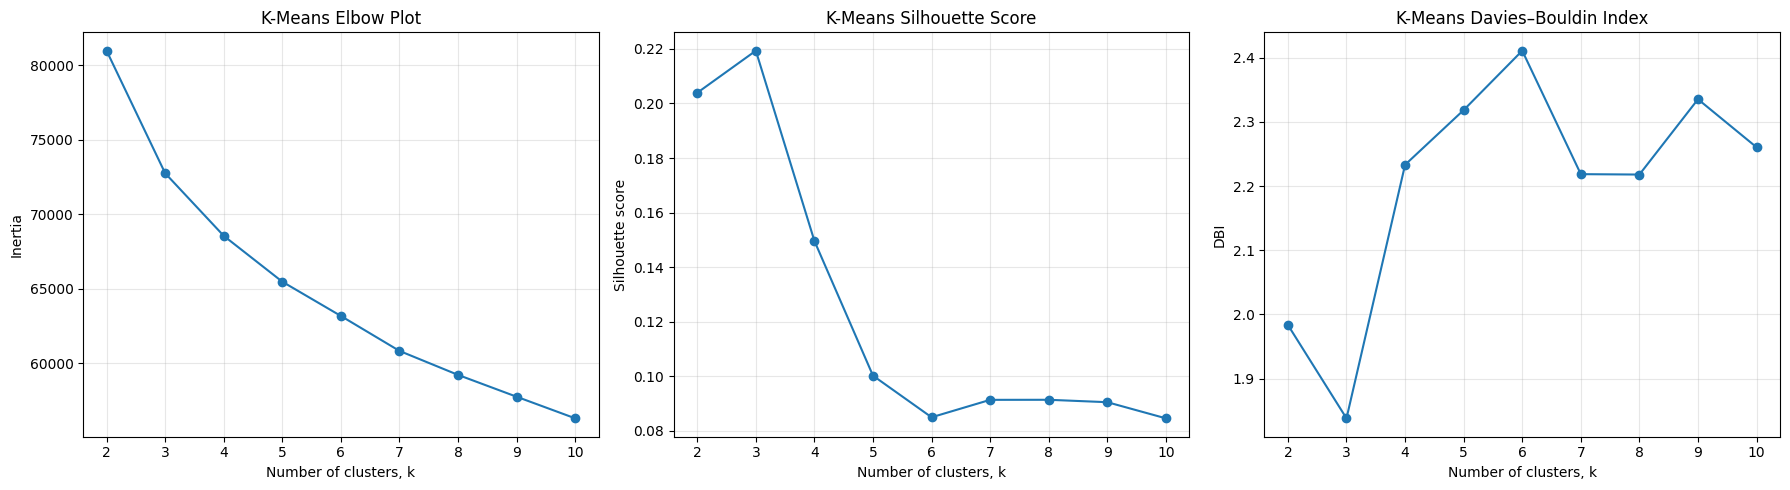


Selected K-Means number of clusters: k = 3
Silhouette score: 0.2193
Davies–Bouldin index: 1.8382


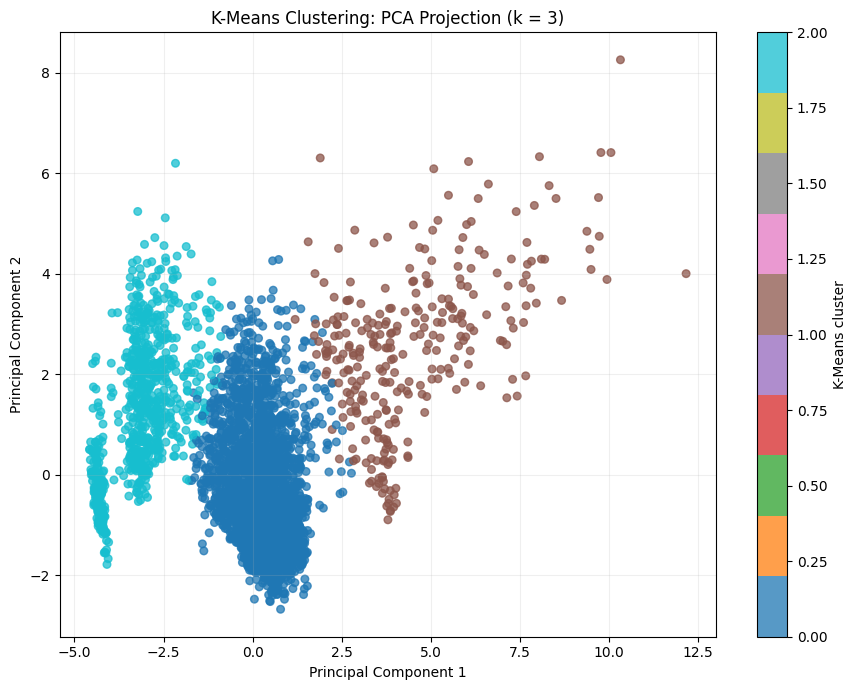


K-Means cluster composition by actual outcome (%):


target,Dropout,Enrolled,Graduate
Cluster,,,
0,21.84,20.23,57.93
1,24.66,13.01,62.33
2,80.16,9.79,10.05



Top practical DBSCAN configurations:


,eps,min_samples,clusters,coverage,silhouette
75,4.75,5,2,0.9937,0.5034
66,4.25,10,2,0.9641,0.4467
71,4.50,10,2,0.9790,0.4450
49,3.25,30,2,0.5099,0.3194
54,3.50,30,2,0.6444,0.2953
65,4.25,5,2,0.9763,0.2799
60,4.00,5,4,0.9548,0.2447
55,3.75,5,3,0.9094,0.2309
47,3.25,15,3,0.5927,0.2164
53,3.50,20,4,0.6935,0.1826



Selected DBSCAN configuration:
eps = 4.75
min_samples = 5
clusters = 2
coverage = 99.37%
noise rate = 0.63%


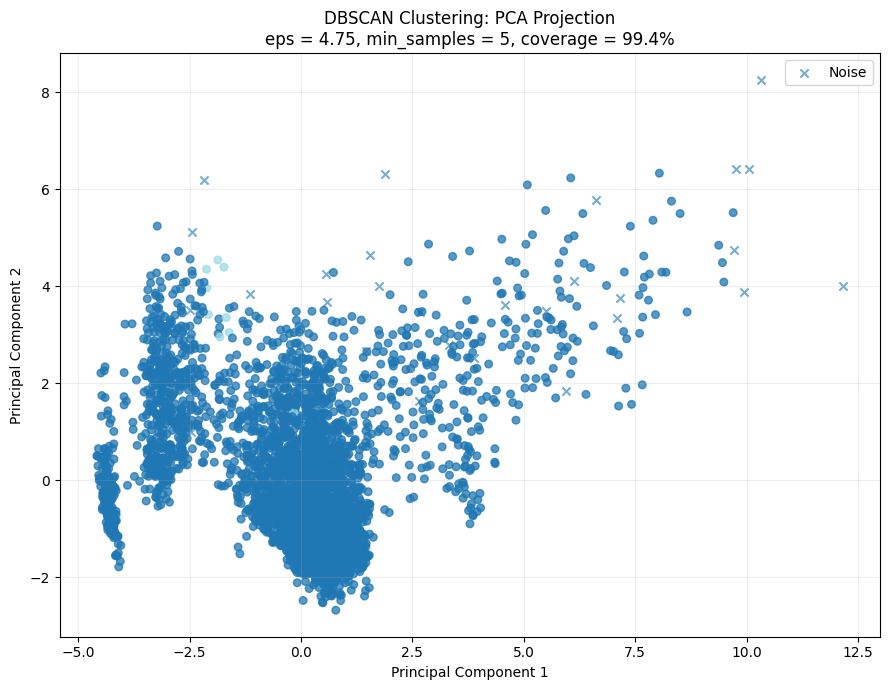


DBSCAN cluster composition by actual outcome (-1 indicates noise):


target,Dropout,Enrolled,Graduate
DBSCAN_Cluster,,,
-1,46.43,7.14,46.43
0,31.96,17.98,50.06
1,66.67,33.33,0.00



Hierarchical clustering validation metrics:


,k,Silhouette,DBI,ARI,NMI
0,2,0.2121,1.9867,0.2075,0.1400
1,3,0.2225,1.8481,0.1724,0.1150
2,4,0.2135,1.5336,0.1733,0.1163
3,5,0.1363,1.8631,0.1972,0.1150
4,6,0.0953,2.0229,0.1464,0.0969
5,7,0.1027,2.0996,0.1178,0.0869
6,8,0.0897,2.1079,0.0826,0.0797
7,9,0.0692,2.1325,0.0551,0.0754
8,10,0.0695,2.1414,0.0546,0.0742


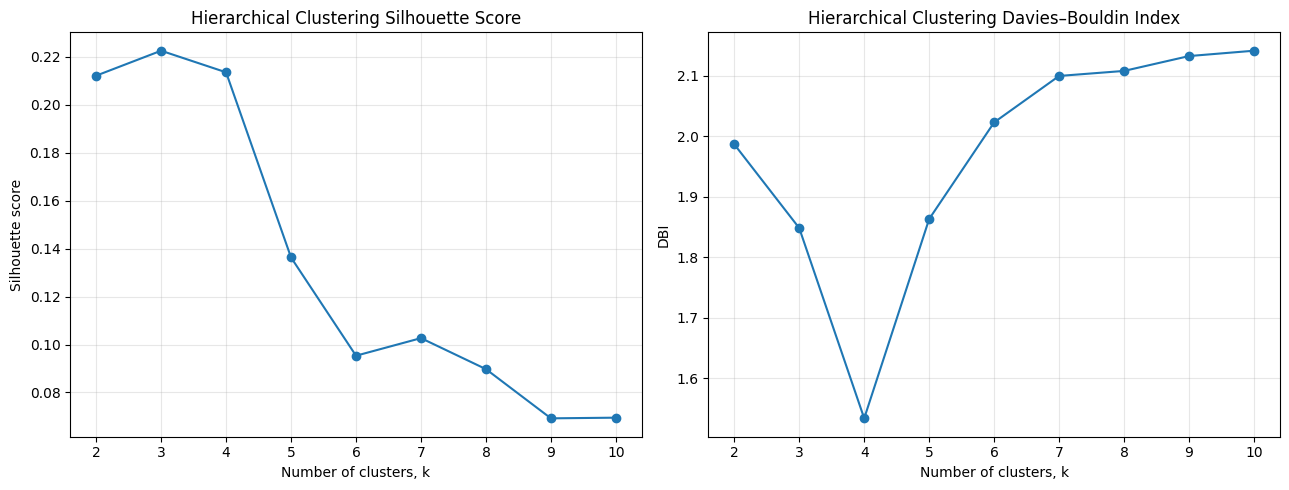


Selected hierarchical number of clusters: k = 3


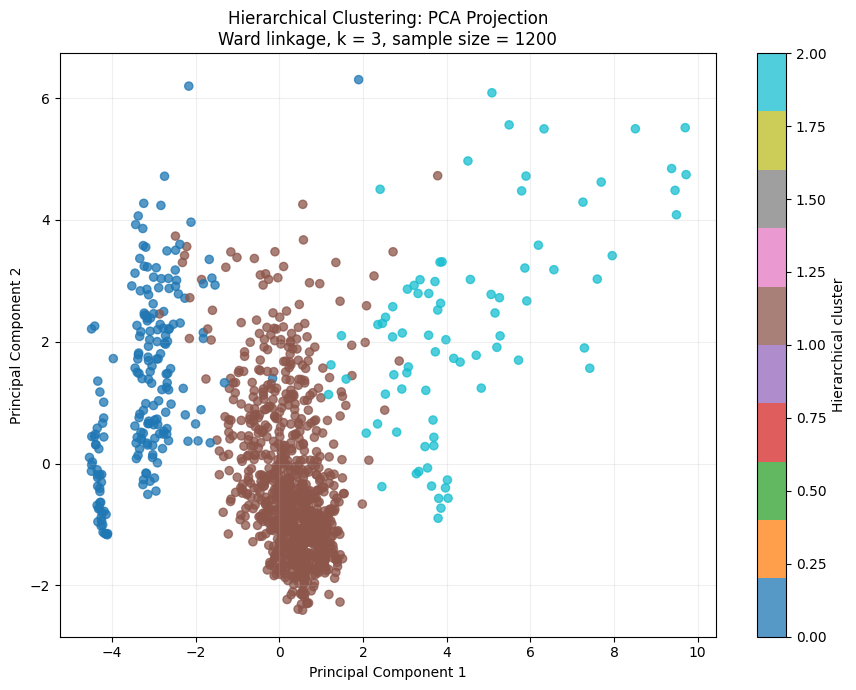


Hierarchical cluster composition by actual outcome (%):


Target,0,1
Cluster,,
0,23.04,76.96
1,74.35,25.65
2,75.31,24.69


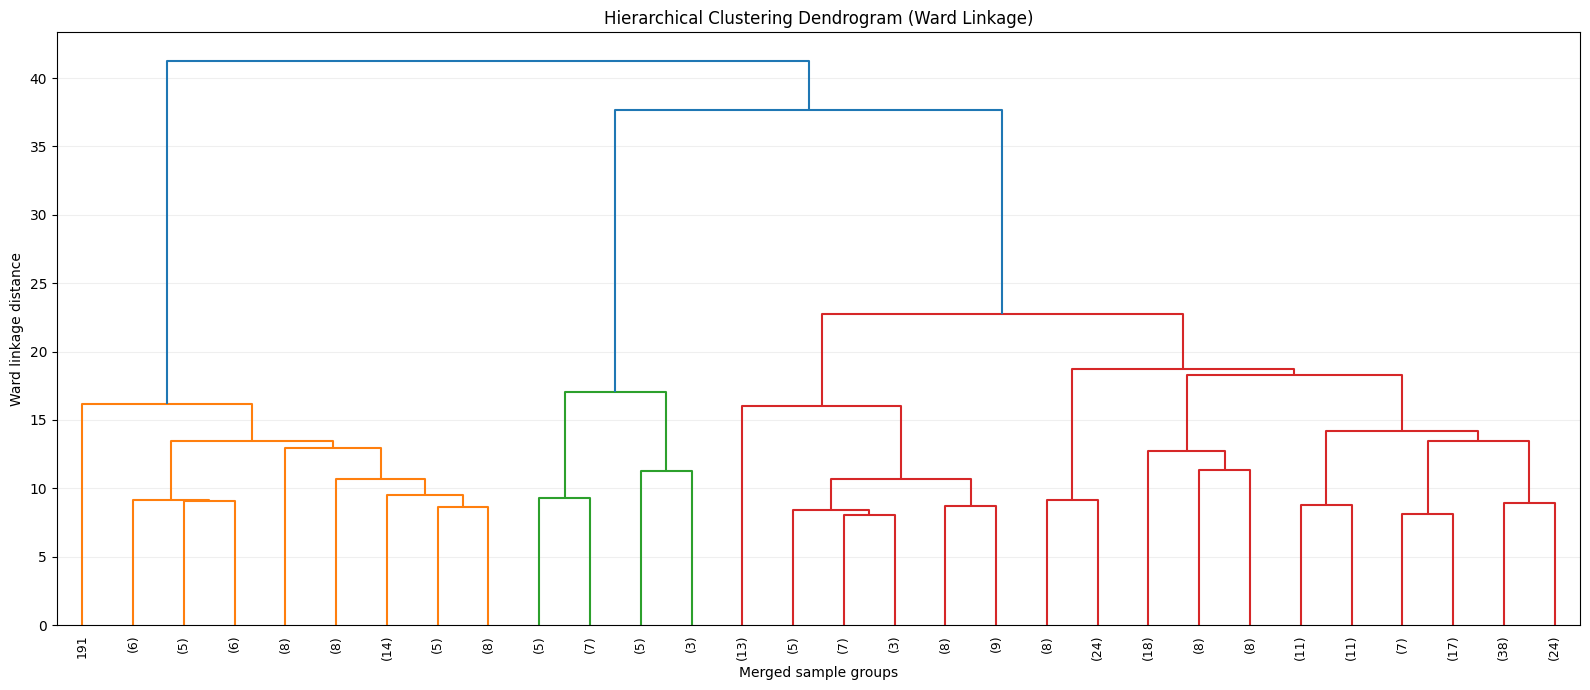


UNSUPERVISED-LEARNING SUMMARY
-------------------------------------------------------
K-Means:
  Selected k = 3
  Silhouette = 0.2193
  DBI = 1.8382


DBSCAN:
  eps = 4.75
  min_samples = 5
  Clusters = 2
  Coverage = 99.37%
  Silhouette = 0.5034


Hierarchical clustering:
  Selected k = 3
  Sample size = 1200
  Silhouette = 0.2225
  DBI = 1.8481


In [84]:

# ------------------------------------------------------------
# Prepare the feature matrix
# ------------------------------------------------------------

Xc = df_fe[FEATURE_SETS["After first semester"]]

pre, _, _ = preprocessor_for(Xc)

Z = pre.fit_transform(Xc)

# Convert sparse matrix to dense array when necessary
Z = Z.toarray() if hasattr(Z, "toarray") else Z

# Retain enough principal components to explain 95% of variance
pca_cluster = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE
)

Zp = pca_cluster.fit_transform(Z)

print(f"Original processed dimensions: {Z.shape[1]}")
print(f"PCA dimensions retained: {Zp.shape[1]}")
print(
    f"Explained variance retained: "
    f"{pca_cluster.explained_variance_ratio_.sum():.4f}"
)


# ------------------------------------------------------------
# Create a two-dimensional PCA projection for plotting
# ------------------------------------------------------------
# The clustering models use Zp, which may contain more than two
# dimensions. A separate 2D PCA projection is used only for
# visualization.

pca_plot = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

Z2 = pca_plot.fit_transform(Z)

print(
    f"Variance shown in 2D plots: "
    f"{pca_plot.explained_variance_ratio_.sum():.4f}"
)


# ============================================================
# K-MEANS CLUSTERING
# ============================================================

ke = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        n_init=30,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(Zp)

    ke.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(Zp, labels),
        "DBI": davies_bouldin_score(Zp, labels),
        "ARI": adjusted_rand_score(y, labels),
        "NMI": normalized_mutual_info_score(y, labels)
    })

ke = pd.DataFrame(ke)

print("\nK-Means validation metrics:")
display(ke.round(4))


# ------------------------------------------------------------
# Plot K-Means validation metrics
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    ke["k"],
    ke["Inertia"],
    marker="o"
)
axes[0].set_title("K-Means Elbow Plot")
axes[0].set_xlabel("Number of clusters, k")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(
    ke["k"],
    ke["Silhouette"],
    marker="o"
)
axes[1].set_title("K-Means Silhouette Score")
axes[1].set_xlabel("Number of clusters, k")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(alpha=0.3)

axes[2].plot(
    ke["k"],
    ke["DBI"],
    marker="o"
)
axes[2].set_title("K-Means Davies–Bouldin Index")
axes[2].set_xlabel("Number of clusters, k")
axes[2].set_ylabel("DBI")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Select and fit the best K-Means model
# ------------------------------------------------------------

bestk = int(
    ke.sort_values(
        ["Silhouette", "DBI"],
        ascending=[False, True]
    ).iloc[0]["k"]
)

km = KMeans(
    n_clusters=bestk,
    n_init=30,
    random_state=RANDOM_STATE
)

kmeans_labels = km.fit_predict(Zp)

print(f"\nSelected K-Means number of clusters: k = {bestk}")
print(
    f"Silhouette score: "
    f"{silhouette_score(Zp, kmeans_labels):.4f}"
)
print(
    f"Davies–Bouldin index: "
    f"{davies_bouldin_score(Zp, kmeans_labels):.4f}"
)


# ------------------------------------------------------------
# Plot K-Means clusters
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    Z2[:, 0],
    Z2[:, 1],
    c=kmeans_labels,
    cmap="tab10",
    s=30,
    alpha=0.75
)

plt.title(
    f"K-Means Clustering: PCA Projection "
    f"(k = {bestk})"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

cbar = plt.colorbar(scatter)
cbar.set_label("K-Means cluster")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# K-Means cluster composition by actual target
# ------------------------------------------------------------

dfc = df_fe.copy()
dfc["Cluster"] = kmeans_labels

kmeans_target_distribution = (
    pd.crosstab(
        dfc["Cluster"],
        dfc["target"],
        normalize="index"
    ) * 100
)

print("\nK-Means cluster composition by actual outcome (%):")
display(kmeans_target_distribution.round(2))


# ============================================================
# PRACTICAL DBSCAN
# ============================================================
# Candidate DBSCAN models must retain at least 50% of the
# observations as non-noise points.

db = []

for eps in np.arange(1.0, 5.1, 0.25):

    for min_samples in [5, 10, 15, 20, 30]:

        labels = DBSCAN(
            eps=float(eps),
            min_samples=min_samples
        ).fit_predict(Zp)

        non_noise_mask = labels != -1
        coverage = non_noise_mask.mean()

        number_of_clusters = len(
            set(labels) - {-1}
        )

        if number_of_clusters >= 2 and coverage >= 0.50:

            dbscan_silhouette = silhouette_score(
                Zp[non_noise_mask],
                labels[non_noise_mask]
            )

        else:
            dbscan_silhouette = np.nan

        db.append({
            "eps": float(eps),
            "min_samples": min_samples,
            "clusters": number_of_clusters,
            "coverage": coverage,
            "silhouette": dbscan_silhouette
        })

db = pd.DataFrame(db)

valid_dbscan = (
    db.dropna(subset=["silhouette"])
      .sort_values(
          ["silhouette", "coverage"],
          ascending=[False, False]
      )
)

print("\nTop practical DBSCAN configurations:")
display(valid_dbscan.head(20).round(4))


# ------------------------------------------------------------
# Fit and plot the best valid DBSCAN model
# ------------------------------------------------------------

if len(valid_dbscan) > 0:

    best_dbscan = valid_dbscan.iloc[0]

    best_eps = float(best_dbscan["eps"])
    best_min_samples = int(best_dbscan["min_samples"])

    dbscan_model = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples
    )

    dbscan_labels = dbscan_model.fit_predict(Zp)

    dbscan_mask = dbscan_labels != -1
    dbscan_clusters = len(
        set(dbscan_labels) - {-1}
    )
    dbscan_coverage = dbscan_mask.mean()
    dbscan_noise_rate = 1 - dbscan_coverage

    print(
        f"\nSelected DBSCAN configuration:"
        f"\neps = {best_eps:.2f}"
        f"\nmin_samples = {best_min_samples}"
        f"\nclusters = {dbscan_clusters}"
        f"\ncoverage = {dbscan_coverage:.2%}"
        f"\nnoise rate = {dbscan_noise_rate:.2%}"
    )

    plt.figure(figsize=(9, 7))

    # Plot noise points separately
    plt.scatter(
        Z2[dbscan_labels == -1, 0],
        Z2[dbscan_labels == -1, 1],
        marker="x",
        s=35,
        alpha=0.60,
        label="Noise"
    )

    # Plot non-noise cluster points
    dbscan_scatter = plt.scatter(
        Z2[dbscan_labels != -1, 0],
        Z2[dbscan_labels != -1, 1],
        c=dbscan_labels[dbscan_labels != -1],
        cmap="tab20",
        s=30,
        alpha=0.75
    )

    plt.title(
        "DBSCAN Clustering: PCA Projection\n"
        f"eps = {best_eps:.2f}, "
        f"min_samples = {best_min_samples}, "
        f"coverage = {dbscan_coverage:.1%}"
    )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


    # DBSCAN cluster composition
    df_dbscan = df_fe.copy()
    df_dbscan["DBSCAN_Cluster"] = dbscan_labels

    dbscan_target_distribution = (
        pd.crosstab(
            df_dbscan["DBSCAN_Cluster"],
            df_dbscan["target"],
            normalize="index"
        ) * 100
    )

    print(
        "\nDBSCAN cluster composition by actual outcome "
        "(-1 indicates noise):"
    )

    display(dbscan_target_distribution.round(2))

else:

    print(
        "\nNo DBSCAN configuration satisfied all practical "
        "requirements:"
        "\n• At least two non-noise clusters"
        "\n• At least 50% observation coverage"
        "\n\nTherefore, no practical DBSCAN cluster plot "
        "was generated."
    )


# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================
# Hierarchical clustering is performed on a reproducible sample
# to avoid excessive computation and memory use.

rng = np.random.RandomState(RANDOM_STATE)

idx = rng.choice(
    len(Zp),
    size=min(1200, len(Zp)),
    replace=False
)

Zh = Zp[idx]
Z2h = Z2[idx]
yh = y.iloc[idx]

he = []

for k in range(2, 11):

    hierarchical_model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    hierarchical_labels = (
        hierarchical_model.fit_predict(Zh)
    )

    he.append({
        "k": k,
        "Silhouette": silhouette_score(
            Zh,
            hierarchical_labels
        ),
        "DBI": davies_bouldin_score(
            Zh,
            hierarchical_labels
        ),
        "ARI": adjusted_rand_score(
            yh,
            hierarchical_labels
        ),
        "NMI": normalized_mutual_info_score(
            yh,
            hierarchical_labels
        )
    })

he = pd.DataFrame(he)

print("\nHierarchical clustering validation metrics:")
display(he.round(4))


# ------------------------------------------------------------
# Plot hierarchical validation metrics
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    he["k"],
    he["Silhouette"],
    marker="o"
)

axes[0].set_title(
    "Hierarchical Clustering Silhouette Score"
)
axes[0].set_xlabel("Number of clusters, k")
axes[0].set_ylabel("Silhouette score")
axes[0].grid(alpha=0.3)

axes[1].plot(
    he["k"],
    he["DBI"],
    marker="o"
)

axes[1].set_title(
    "Hierarchical Clustering Davies–Bouldin Index"
)
axes[1].set_xlabel("Number of clusters, k")
axes[1].set_ylabel("DBI")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Select and fit the best hierarchical model
# ------------------------------------------------------------

best_hierarchical_k = int(
    he.sort_values(
        ["Silhouette", "DBI"],
        ascending=[False, True]
    ).iloc[0]["k"]
)

hierarchical_model = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage="ward"
)

hierarchical_labels = (
    hierarchical_model.fit_predict(Zh)
)

print(
    f"\nSelected hierarchical number of clusters: "
    f"k = {best_hierarchical_k}"
)


# ------------------------------------------------------------
# Plot hierarchical clusters
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

hierarchical_scatter = plt.scatter(
    Z2h[:, 0],
    Z2h[:, 1],
    c=hierarchical_labels,
    cmap="tab10",
    s=35,
    alpha=0.75
)

plt.title(
    "Hierarchical Clustering: PCA Projection\n"
    f"Ward linkage, k = {best_hierarchical_k}, "
    f"sample size = {len(Zh)}"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

cbar = plt.colorbar(hierarchical_scatter)
cbar.set_label("Hierarchical cluster")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Hierarchical cluster composition by target
# ------------------------------------------------------------

hierarchical_results = pd.DataFrame({
    "Cluster": hierarchical_labels,
    "Target": yh.reset_index(drop=True)
})

hierarchical_target_distribution = (
    pd.crosstab(
        hierarchical_results["Cluster"],
        hierarchical_results["Target"],
        normalize="index"
    ) * 100
)

print(
    "\nHierarchical cluster composition by actual outcome (%):"
)

display(hierarchical_target_distribution.round(2))


# ------------------------------------------------------------
# Plot hierarchical dendrogram
# ------------------------------------------------------------
# A smaller subsample is used because a dendrogram containing
# 1,200 individual leaves can be visually overcrowded.

dendrogram_size = min(300, len(Zh))

dendrogram_idx = rng.choice(
    len(Zh),
    size=dendrogram_size,
    replace=False
)

Zd = Zh[dendrogram_idx]

linkage_matrix = linkage(
    Zd,
    method="ward"
)

plt.figure(figsize=(16, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title(
    "Hierarchical Clustering Dendrogram "
    "(Ward Linkage)"
)
plt.xlabel("Merged sample groups")
plt.ylabel("Ward linkage distance")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


# ============================================================
# FINAL UNSUPERVISED-LEARNING SUMMARY
# ============================================================

print("\nUNSUPERVISED-LEARNING SUMMARY")
print("-" * 55)

print(
    f"K-Means:"
    f"\n  Selected k = {bestk}"
    f"\n  Silhouette = "
    f"{silhouette_score(Zp, kmeans_labels):.4f}"
    f"\n  DBI = "
    f"{davies_bouldin_score(Zp, kmeans_labels):.4f}"
)

if len(valid_dbscan) > 0:

    print(
        f"\n\nDBSCAN:"
        f"\n  eps = {best_eps:.2f}"
        f"\n  min_samples = {best_min_samples}"
        f"\n  Clusters = {dbscan_clusters}"
        f"\n  Coverage = {dbscan_coverage:.2%}"
        f"\n  Silhouette = "
        f"{best_dbscan['silhouette']:.4f}"
    )

else:

    print(
        "\n\nDBSCAN:"
        "\n  No configuration met the practical "
        "coverage and cluster requirements."
    )

print(
    f"\n\nHierarchical clustering:"
    f"\n  Selected k = {best_hierarchical_k}"
    f"\n  Sample size = {len(Zh)}"
    f"\n  Silhouette = "
    f"{silhouette_score(Zh, hierarchical_labels):.4f}"
    f"\n  DBI = "
    f"{davies_bouldin_score(Zh, hierarchical_labels):.4f}"
)


## Cell 24 — Business KPI translation

In [85]:

# Converts the final model performance into operational metrics
# that are easier for institutional decision-makers to interpret.


# ------------------------------------------------------------
# Extract confusion-matrix values
# ------------------------------------------------------------

true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix(
        y_test,
        final_predictions
    ).ravel()
)


# ------------------------------------------------------------
# Calculate operational business KPIs
# ------------------------------------------------------------

business_kpis = pd.DataFrame([
    {
        "KPI": "Actual dropouts identified",
        "Value": true_positive
    },
    {
        "KPI": "Actual dropouts missed",
        "Value": false_negative
    },
    {
        "KPI": "Students flagged for review",
        "Value": true_positive + false_positive
    },
    {
        "KPI": "True dropouts per 100 alerts",
        "Value": (
            precision_score(
                y_test,
                final_predictions,
                zero_division=0
            ) * 100
        )
    },
    {
        "KPI": "Dropout detection rate (%)",
        "Value": (
            recall_score(
                y_test,
                final_predictions,
                zero_division=0
            ) * 100
        )
    },
    {
        "KPI": "Students reviewed per true dropout",
        "Value": (
            (true_positive + false_positive)
            / true_positive
            if true_positive > 0
            else np.nan
        )
    }
])


# ------------------------------------------------------------
# Display business KPIs
# ------------------------------------------------------------

print("Operational business KPIs:")
display(
    business_kpis.round(2)
)


# ------------------------------------------------------------
# Save KPI summary
# ------------------------------------------------------------

kpi_path = (
    PATHS["tables"] /
    "business_kpis.csv"
)

business_kpis.to_csv(
    kpi_path,
    index=False
)

print(f"\nBusiness KPI summary saved to:\n{kpi_path.resolve()}")

Operational business KPIs:


,KPI,Value
0,Actual dropouts identified,242.00
1,Actual dropouts missed,42.00
2,Students flagged for review,339.00
3,True dropouts per 100 alerts,71.39
4,Dropout detection rate (%),85.21
5,Students reviewed per true dropout,1.40



Business KPI summary saved to:
/content/reports/tables/business_kpis.csv


#Github Repository

### Create `README.md`

This file serves as the main project page displayed by GitHub.


In [86]:
# Creates a project-specific README.md file in the repository root.

readme_content = """# Explainable Machine Learning for Early Dropout Prediction and Student Segmentation in Higher Education

## Overview

This repository contains the Google Colab implementation of an AI/ML capstone project
that develops an explainable machine learning framework for early student-dropout
prediction and student segmentation in higher education.

The study uses the UCI **Predict Students' Dropout and Academic Success** dataset.
It integrates supervised classification, feature engineering, model calibration,
classification-threshold optimization, explainable artificial intelligence, fairness
assessment, and unsupervised clustering.

## Study Objectives

1. Develop models for predicting student dropout at different intervention horizons.
2. Compare Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,
   and Support Vector Machine classifiers.
3. Identify influential predictors through feature importance, SHAP, and partial
   dependence analysis.
4. Evaluate model performance across selected demographic and socioeconomic groups.
5. Segment students using K-Means, DBSCAN, and Agglomerative Clustering.
6. Translate model outputs into operational indicators for student-support planning.

## Dataset

- **Source:** UCI Machine Learning Repository
- **Dataset:** Predict Students' Dropout and Academic Success
- **Observations:** 4,424 students
- **Original variables:** 37
- **Outcome classes:** Graduate, Dropout, and Enrolled
- **Modeling target:** Binary dropout outcome
- **Prediction horizons:** Admission, after the first semester, and after the second semester

The notebook downloads the dataset automatically to:

```text
data/raw/student_dropout_data.csv
```

## Methods

The analysis includes:

- Data-quality assessment and exploratory data analysis
- Feature engineering and prediction-horizon construction
- Preprocessing with imputation, scaling, and one-hot encoding
- Mutual-information feature selection
- Principal Component Analysis
- Stratified train-test splitting and cross-validation
- Grid-search hyperparameter optimization
- Probability calibration and threshold optimization
- Classification performance evaluation
- SHAP, permutation importance, and partial dependence analysis
- Group-based fairness assessment
- K-Means, DBSCAN, and Agglomerative Clustering
- Operational KPI calculation

## Main Operational Model

The operational model uses information available after the first semester. Based on
the completed study run, Logistic Regression provided a strong balance of predictive
performance, probability quality, interpretability, and practical usefulness.

Reported held-out test performance at the selected operating threshold:

| Metric | Value |
|---|---:|
| Accuracy | 84.3% |
| Balanced Accuracy | 84.5% |
| Precision | 71.4% |
| Recall | 85.2% |
| F1-score | 77.7% |
| ROC-AUC | 0.913 |
| PR-AUC | 0.877 |
| Brier score | 0.098 |

These values should be interpreted as results from this dataset and validation design,
not as evidence of causal effects or guaranteed performance at another institution.

## Repository Structure

```text
.
├── Eduardo_Magdaluyo_Jr_Capstone_Project_GitHub_Colab.ipynb
├── README.md
├── requirements.txt
├── LICENSE
├── .gitignore
├── data/
│   ├── raw/
│   └── processed/
├── models/
├── reports/
│   ├── figures/
│   └── tables/
├── configs/
├── notebooks/
└── slides/
```

## Running the Notebook in Google Colab

1. Open the `.ipynb` file in Google Colab.
2. Select **Runtime > Run all**.
3. Allow the package-installation cell to finish.
4. The dataset will be downloaded automatically when it is not yet available.
5. Generated figures, tables, models, and configuration files will be saved in their
   corresponding project folders.
6. Download the generated outputs from the Colab Files panel before ending the runtime,
   because files stored under `/content` are temporary.

## Reproducibility

The notebook uses a fixed random seed, a stratified 80/20 train-test split,
stratified five-fold cross-validation, and saved run configuration metadata.

## Author

**Eduardo R. Magdaluyo, Jr.**
Capstone Project
Post Graduate Diploma in AI/ML
Asian Institute of Management

## License

This project is distributed under the MIT License. See `LICENSE` for details.
"""

readme_path = ROOT / "README.md"
readme_path.write_text(readme_content, encoding="utf-8")

print(f"README.md created at:\n{readme_path.resolve()}")


README.md created at:
/content/README.md


### Create `requirements.txt`

This file records the principal Python packages needed to reproduce the notebook.


In [87]:
# Creates requirements.txt using broadly compatible minimum versions.
# Google Colab already includes several of these packages, but listing
# them makes the repository reproducible outside the current runtime.

requirements_content = """numpy>=1.24
pandas>=2.0
matplotlib>=3.7
scipy>=1.10
scikit-learn>=1.3
joblib>=1.3
gdown>=5.0
shap>=0.44
fairlearn>=0.10
openpyxl>=3.1
tabulate>=0.9
ipython>=8.0
"""

requirements_path = ROOT / "requirements.txt"
requirements_path.write_text(requirements_content, encoding="utf-8")

print(f"requirements.txt created at:\n{requirements_path.resolve()}")


requirements.txt created at:
/content/requirements.txt


### Create `LICENSE`

The MIT License permits reuse and modification while retaining the copyright notice.


In [88]:
# Creates the MIT License file.

license_content = """MIT License

Copyright (c) 2026 Eduardo R. Magdaluyo, Jr.

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
"""

license_path = ROOT / "LICENSE"
license_path.write_text(license_content, encoding="utf-8")

print(f"LICENSE created at:\n{license_path.resolve()}")


LICENSE created at:
/content/LICENSE


### Create `.gitignore`

This file prevents temporary Colab, Python, model, and editor files from cluttering
the GitHub repository.


In [89]:
# Creates a .gitignore suitable for a Google Colab/Python ML project.

gitignore_content = """# Python cache and compiled files
__pycache__/
*.py[cod]
*$py.class

# Jupyter and Google Colab checkpoints
.ipynb_checkpoints/

# Virtual environments
.venv/
venv/
env/

# IDE and editor settings
.vscode/
.idea/

# Operating-system files
.DS_Store
Thumbs.db

# Logs and temporary files
*.log
*.tmp
*.temp

# Local environment and secrets
.env
.env.*
credentials.json
service_account*.json

# Large generated artifacts
*.pkl
*.pickle
*.joblib

# Optional generated output folders
# Uncomment these entries when generated outputs should not be tracked.
# models/
# reports/figures/
# reports/tables/
# data/processed/

# Raw dataset
# Keep this ignored when redistribution is not intended.
data/raw/*.csv
"""

gitignore_path = ROOT / ".gitignore"
gitignore_path.write_text(gitignore_content, encoding="utf-8")

print(f".gitignore created at:\n{gitignore_path.resolve()}")


.gitignore created at:
/content/.gitignore
